# Analyse Visa Premier - Presentation Strategique
## Classification automatique de la clientele et disposition envers la carte haut de gamme

Objectif: Analyser les profils clients et identifier les segments cibles pour renforcer la fidelisation aupres de la clientele aisee.

## 1. Chargement et Exploration des Donnees

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Configuration du style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [155]:
# Installation de mlxtend pour les règles d'association
import subprocess
import sys

try:
    import mlxtend
    print("✓ mlxtend est déjà installé")
except ImportError:
    print("Installation de mlxtend...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "mlxtend", "-q"])
    print("✓ mlxtend installé avec succès")


Installation de mlxtend...
✓ mlxtend installé avec succès


In [71]:
# Chargement du fichier VISA (format Excel)
# Chargement du fichier VISA (format Excel)
df = pd.read_excel('VISA.xlsx')
print("Dimensions du dataset:")
df.shape

Dimensions du dataset:


(1073, 48)

In [72]:
print("\nPremiers enregistrements:")
df.head()


Premiers enregistrements:


,matricul,departem,ptvente,sexe,age,sitfamil,anciente,csp,codeqlt,nbimpaye,...,mtbon,nbpaiecb,nbcb,nbcbptar,avtscpte,aveparfi,cartevp,sexer,cartevpr,nbjdebit
0,148009,31,1,Shom,51,Fmar,238,Pcad,A,0,...,0,14,2,0,1303700,556967,Coui,0,1,1
1,442153,82,6,Shom,52,Fmar,270,Pcad,A,0,...,19500000,5,2,0,19856243,133896,Coui,0,1,0
2,552427,97,1,Shom,58,Fmar,139,Pcad,C,0,...,0,0,1,0,122745,0,Coui,0,1,0
3,556005,40,1,Shom,27,Fcel,99,Psan,B,0,...,0,14,2,0,83224,0,Coui,0,1,0
4,556686,65,1,Shom,49,Fsep,89,Pemp,A,0,...,0,11,3,1,494773,21423,Coui,0,1,15


In [73]:
print("\nTypes de donnees:")
print(df.dtypes)


Types de donnees:
matricul     int64
departem    object
ptvente      int64
sexe           str
age          int64
sitfamil       str
anciente     int64
csp            str
codeqlt        str
nbimpaye     int64
mtrejet      int64
nbopguic     int64
moycred3     int64
aveparmo     int64
endette      int64
engagemt     int64
engagemc     int64
engagemm     int64
nbcptvue     int64
moysold3     int64
moycredi     int64
agemvt      object
nbop         int64
mtfactur     int64
engageml     int64
nbvie        int64
mtvie        int64
nbeparmo     int64
mteparmo     int64
nbeparlo     int64
mteparlo     int64
nblivret     int64
mtlivret     int64
nbeparlt     int64
mteparlt     int64
nbeparte     int64
mteparte     int64
nbbon        int64
mtbon        int64
nbpaiecb    object
nbcb         int64
nbcbptar     int64
avtscpte     int64
aveparfi     int64
cartevp        str
sexer        int64
cartevpr     int64
nbjdebit     int64
dtype: object


In [74]:
print("ValFrancs manquantes:")
print(df.isnull().sum())

Valeurs manquantes:
matricul    0
departem    0
ptvente     0
sexe        0
age         0
sitfamil    0
anciente    0
csp         0
codeqlt     0
nbimpaye    0
mtrejet     0
nbopguic    0
moycred3    0
aveparmo    0
endette     0
engagemt    0
engagemc    0
engagemm    0
nbcptvue    0
moysold3    0
moycredi    0
agemvt      0
nbop        0
mtfactur    0
engageml    0
nbvie       0
mtvie       0
nbeparmo    0
mteparmo    0
nbeparlo    0
mteparlo    0
nblivret    0
mtlivret    0
nbeparlt    0
mteparlt    0
nbeparte    0
mteparte    0
nbbon       0
mtbon       0
nbpaiecb    0
nbcb        0
nbcbptar    0
avtscpte    0
aveparfi    0
cartevp     0
sexer       0
cartevpr    0
nbjdebit    0
dtype: int64


## 2. Nettoyage et Preparation des Donnees

In [75]:
# Dictionnaire de renommage des colonnes pour plus de clarté
rename_dict = {
    'matricul': 'ID_Client',
    'departem': 'Departement',
    'ptvente': 'Point_Vente',
    'sexe': 'Sexe',
    'age': 'Age',
    'sitfamil': 'Situation_Familiale',
    'anciente': 'Anciennete_Jours',
    'csp': 'Categorie_Socio_Pro',
    'codeqlt': 'Code_Qualite',
    'nbimpaye': 'Nb_Impayés',
    'mtrejet': 'Montant_Rejets',
    'nbopguic': 'Nb_Op_Guichet',
    'moycred3': 'Moyenne_Credit_3m',
    'aveparmo': 'Avoir_Epargne_Permanente',
    'endette': 'Endettement_Total',
    'engagemt': 'Engagement_Total',
    'engagemc': 'Engagement_Court_Terme',
    'engagemm': 'Engagement_Moyen_Terme',
    'nbcptvue': 'Nb_Comptes_Vue',
    'moysold3': 'Solde_Moyen_3m',
    'moycredi': 'Solde_Moyen_Credit',
    'agemvt': 'Age_Mouvement',
    'nbop': 'Nb_Operations',
    'mtfactur': 'Montant_Facture_Total',
    'engageml': 'Engagement_Long_Terme',
    'nbvie': 'Nb_Produits_Assurance',
    'mtvie': 'Montant_Assurance',
    'nbeparmo': 'Nb_Epargne_Permanente',
    'mteparmo': 'Montant_Epargne_Permanente',
    'nbeparlo': 'Nb_Epargne_Logement',
    'mteparlo': 'Montant_Epargne_Logement',
    'nblivret': 'Nb_Livrets',
    'mtlivret': 'Montant_Livrets',
    'nbeparlt': 'Nb_Epargne_Titre',
    'mteparlt': 'Montant_Epargne_Titre',
    'nbeparte': 'Nb_Epargne_Entreprise',
    'mteparte': 'Montant_Epargne_Entreprise',
    'nbbon': 'Nb_Bons_Achats',
    'mtbon': 'Montant_Bons',
    'nbpaiecb': 'Nb_Paiements_CB',
    'nbcb': 'Nb_Cartes_Bancaires',
    'nbcbptar': 'Nb_CB_Tarification',
    'avtscpte': 'Avoir_Titres_Services',
    'aveparfi': 'Avoir_Epargne_Financiere',
    'cartevp': 'Carte_Visa_Premier',
    'nbjdebit': 'Nb_Debits_Directs'
}

# Renommer les colonnes
df_renamed = df.rename(columns=rename_dict)

print("Colonnes renommees pour clarté (format descriptif):")
print(f"Nombre total de colonnes: {len(df_renamed.columns)}")
print("\nCorrespondance originale -> nouvelle:")
for orig, new in list(rename_dict.items())[:15]:
    print(f"  {orig:15} -> {new}")
print(f"  ... et {len(rename_dict)-15} autres colonnes")

Colonnes renommees pour clarté (format descriptif):
Nombre total de colonnes: 48

Correspondance originale -> nouvelle:
  matricul        -> ID_Client
  departem        -> Departement
  ptvente         -> Point_Vente
  sexe            -> Sexe
  age             -> Age
  sitfamil        -> Situation_Familiale
  anciente        -> Anciennete_Jours
  csp             -> Categorie_Socio_Pro
  codeqlt         -> Code_Qualite
  nbimpaye        -> Nb_Impayés
  mtrejet         -> Montant_Rejets
  nbopguic        -> Nb_Op_Guichet
  moycred3        -> Moyenne_Credit_3m
  aveparmo        -> Avoir_Epargne_Permanente
  endette         -> Endettement_Total
  ... et 31 autres colonnes


In [76]:
df_renamed.head()

,ID_Client,Departement,Point_Vente,Sexe,Age,Situation_Familiale,Anciennete_Jours,Categorie_Socio_Pro,Code_Qualite,Nb_Impayés,...,Montant_Bons,Nb_Paiements_CB,Nb_Cartes_Bancaires,Nb_CB_Tarification,Avoir_Titres_Services,Avoir_Epargne_Financiere,Carte_Visa_Premier,sexer,cartevpr,Nb_Debits_Directs
0,148009,31,1,Shom,51,Fmar,238,Pcad,A,0,...,0,14,2,0,1303700,556967,Coui,0,1,1
1,442153,82,6,Shom,52,Fmar,270,Pcad,A,0,...,19500000,5,2,0,19856243,133896,Coui,0,1,0
2,552427,97,1,Shom,58,Fmar,139,Pcad,C,0,...,0,0,1,0,122745,0,Coui,0,1,0
3,556005,40,1,Shom,27,Fcel,99,Psan,B,0,...,0,14,2,0,83224,0,Coui,0,1,0
4,556686,65,1,Shom,49,Fsep,89,Pemp,A,0,...,0,11,3,1,494773,21423,Coui,0,1,15


In [87]:
# Variable cible: cartevp (Coui/Cnon = Oui/Non pour Visa Premier)
cartevp = df_renamed['Carte_Visa_Premier'].map({'Coui': 1, 'Cnon': 0})

# Selection des variables numeriques principales
numeric_cols = df_renamed.select_dtypes(include=[np.number]).columns.tolist()
exclude_cols = ['matricul', 'ptvente']
X_cols = [col for col in numeric_cols if col not in exclude_cols]

X = df_renamed[X_cols].copy()


print(f"Variables numeriques selectionnees: {X.shape[1]}")
print(f"Nombre de clients: {X.shape[0]}")
print(f"\nVariables incluses:")
for i, col in enumerate(X.columns[:10]):
    display_name = rename_dict.get(col, col)
    print(f"  {i+1:2d}. {display_name}")
print(f"  ... et {len(X.columns)-10} autres variables")

Variables numeriques selectionnees: 40
Nombre de clients: 1073

Variables incluses:
   1. ID_Client
   2. Point_Vente
   3. Age
   4. Anciennete_Jours
   5. Nb_Impayés
   6. Montant_Rejets
   7. Nb_Op_Guichet
   8. Moyenne_Credit_3m
   9. Avoir_Epargne_Permanente
  10. Endettement_Total
  ... et 30 autres variables


In [78]:
# Encodage des variables categoriques importantes pour l'analyse - ONE-HOT ENCODING
# One-Hot Encoding est plus approprié pour K-Means car il évite d'introduire un ordre artificiel

# Selection des variables categoriques pertinentes
categorical_features = ['Sexe', 'Categorie_Socio_Pro', 'Situation_Familiale', 'Code_Qualite']

# Creer une copie pour encodage
X_encoded = X.copy()

print("\nOne-Hot Encoding des variables categoriques:")
print("=" * 70)

# Appliquer get_dummies pour chaque variable catégorique
for cat_var in categorical_features:
    if cat_var in df_renamed.columns:
        # Récupérer les classes uniques
        n_classes = df_renamed[cat_var].nunique()
        unique_classes = sorted(df_renamed[cat_var].unique())
        
        print(f"\n{cat_var}:")
        print(f"  Nombre de classes: {n_classes}")
        print(f"  Classes: {unique_classes}")
        
        # One-Hot Encoding
        dummies = pd.get_dummies(df_renamed[cat_var], prefix=cat_var, drop_first=False)
        
        # Supprimer la colonne originale et ajouter les dummies
        X_encoded = X_encoded.drop(columns=[cat_var], errors='ignore')
        X_encoded = pd.concat([X_encoded, dummies], axis=1)
        
        print(f"  → {n_classes} nouvelles colonnes binaires créées")


One-Hot Encoding des variables categoriques:

Sexe:
  Nombre de classes: 2
  Classes: ['Sfem', 'Shom']
  → 2 nouvelles colonnes binaires créées

Categorie_Socio_Pro:
  Nombre de classes: 8
  Classes: ['Pagri', 'Part', 'Pcad', 'Pemp', 'Pinc', 'Pouv', 'Pret', 'Psan']
  → 8 nouvelles colonnes binaires créées

Situation_Familiale:
  Nombre de classes: 7
  Classes: ['F.', 'Fcel', 'Fdiv', 'Fmar', 'Fsep', 'Fuli', 'Fveu']
  → 7 nouvelles colonnes binaires créées

Code_Qualite:
  Nombre de classes: 6
  Classes: ['.', 'A', 'B', 'C', 'D', 'E']
  → 6 nouvelles colonnes binaires créées


In [88]:
# Afficher toutes les colonnes
print(df.columns.tolist())
print(f"\nNombre total de colonnes: {len(df.columns)}")
print("\nAperçu du dataframe:")
print(df.head())


['matricul', 'departem', 'ptvente', 'sexe', 'age', 'sitfamil', 'anciente', 'csp', 'codeqlt', 'nbimpaye', 'mtrejet', 'nbopguic', 'moycred3', 'aveparmo', 'endette', 'engagemt', 'engagemc', 'engagemm', 'nbcptvue', 'moysold3', 'moycredi', 'agemvt', 'nbop', 'mtfactur', 'engageml', 'nbvie', 'mtvie', 'nbeparmo', 'mteparmo', 'nbeparlo', 'mteparlo', 'nblivret', 'mtlivret', 'nbeparlt', 'mteparlt', 'nbeparte', 'mteparte', 'nbbon', 'mtbon', 'nbpaiecb', 'nbcb', 'nbcbptar', 'avtscpte', 'aveparfi', 'cartevp', 'sexer', 'cartevpr', 'nbjdebit', 'Cluster', 'CartePremier']

Nombre total de colonnes: 50

Aperçu du dataframe:
   matricul departem  ptvente  sexe  age sitfamil  anciente   csp codeqlt  \
0    148009       31        1  Shom   51     Fmar       238  Pcad       A   
1    442153       82        6  Shom   52     Fmar       270  Pcad       A   
2    552427       97        1  Shom   58     Fmar       139  Pcad       C   
3    556005       40        1  Shom   27     Fcel        99  Psan       B   
4  

In [89]:
# Standardisation COMPLETE avec variables numeriques ET categoriques one-hot-encodées
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

print(f"\nVariables finales apres One-Hot Encoding:")
print(f"  Variables numeriques originales: {len(X_cols)}")
print(f"  Variables categoriques (one-hot): {X_encoded.shape[1] - len(X_cols)}")
print(f"  Total: {X_encoded.shape[1]} variables")
print(f"\nDonnees standardisees - Moyenne: {X_scaled.mean(axis=0)[:5].round(10)}")
print(f"Donnees standardisees - Ecart-type: {X_scaled.std(axis=0)[:5]}")


Variables finales apres One-Hot Encoding:
  Variables numeriques originales: 40
  Variables categoriques (one-hot): 23
  Total: 63 variables

Donnees standardisees - Moyenne: [ 0. -0. -0. -0.  0.]
Donnees standardisees - Ecart-type: [1. 1. 1. 1. 0.]


## 3. Analyse Descriptive - Profil de la Clientele

**Note importante:** 
- Les colonnes ont ete renommees avec des etiquettes descriptives pour une meillFrance comprehension
- Les 37 variables numeriques incluses couvrent TOUS les domaines: profil demographique, comportement transactionnel, engagements, epargne et produits bancaires

In [95]:
# Statistiques clés
print("STATISTIQUES DESCRIPTIVES")
print("=" * 80)
print(f"\nDisposition envers Visa Premier:")
print(f"  - Oui (Coui): {cartevp.sum()} clients ({cartevp.mean()*100:.1f}%)")
print(f"  - Non (Cnon): {(1-cartevp).sum()} clients ({(1-cartevp).mean()*100:.1f}%)")

print(f"\nTOUTES LES VARIABLES - Statistiques descriptives:")
print(X.describe().round(2).to_string())

STATISTIQUES DESCRIPTIVES

Disposition envers Visa Premier:
  - Oui (Coui): 359 clients (33.5%)
  - Non (Cnon): 714 clients (66.5%)

TOUTES LES VARIABLES - Statistiques descriptives:
       ID_Client  Point_Vente      Age  Anciennete_Jours  Nb_Impayés  Montant_Rejets  Nb_Op_Guichet  Moyenne_Credit_3m  Avoir_Epargne_Permanente  Endettement_Total  Engagement_Total  Engagement_Court_Terme  Engagement_Moyen_Terme  Nb_Comptes_Vue  Solde_Moyen_3m  Solde_Moyen_Credit  Nb_Operations  Montant_Facture_Total  Engagement_Long_Terme  Nb_Produits_Assurance  Montant_Assurance  Nb_Epargne_Permanente  Montant_Epargne_Permanente  Nb_Epargne_Logement  Montant_Epargne_Logement  Nb_Livrets  Montant_Livrets  Nb_Epargne_Titre  Montant_Epargne_Titre  Nb_Epargne_Entreprise  Montant_Epargne_Entreprise  Nb_Bons_Achats  Montant_Bons  Nb_Cartes_Bancaires  Nb_CB_Tarification  Avoir_Titres_Services  Avoir_Epargne_Financiere    sexer  cartevpr  Nb_Debits_Directs
count     1073.0      1073.00  1073.00           1073.0


DISTRIBUTIONS COMPARATIVES - TOUTES LES VARIABLES


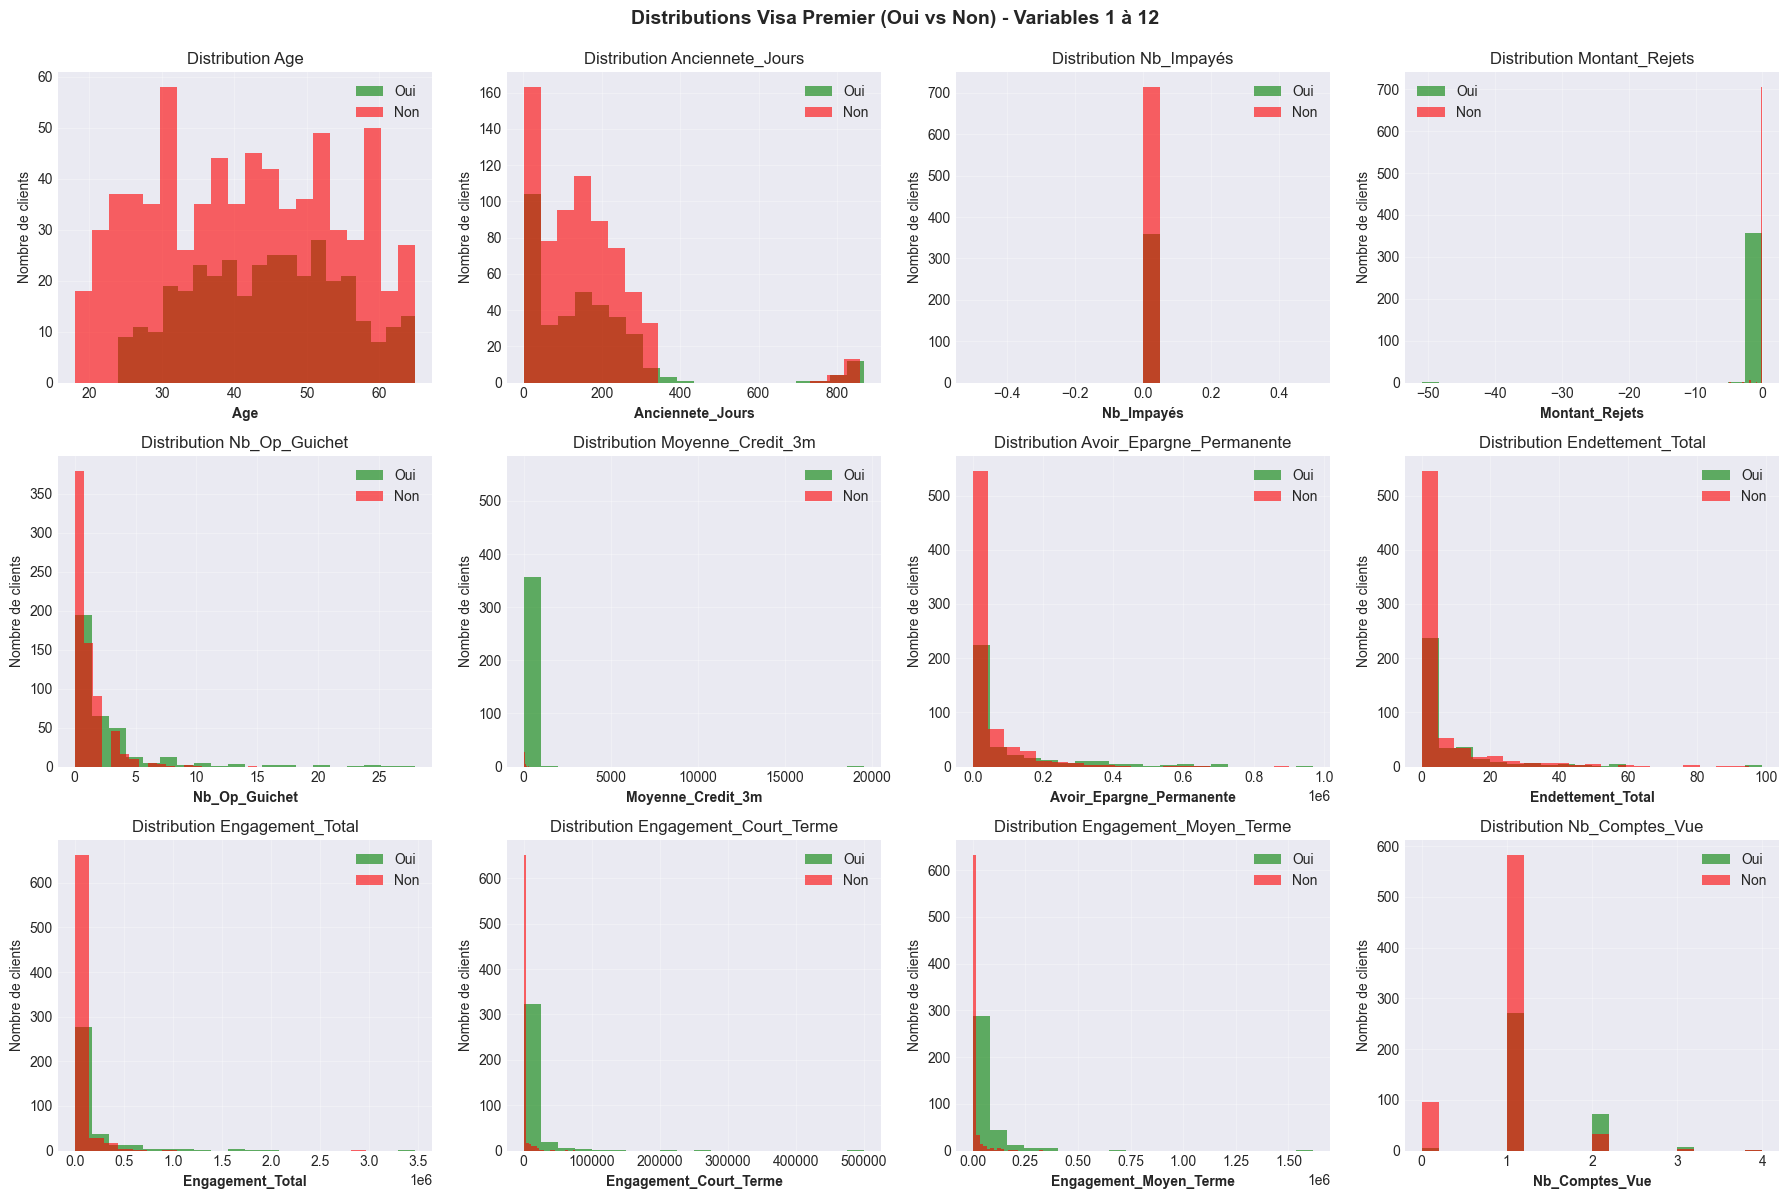

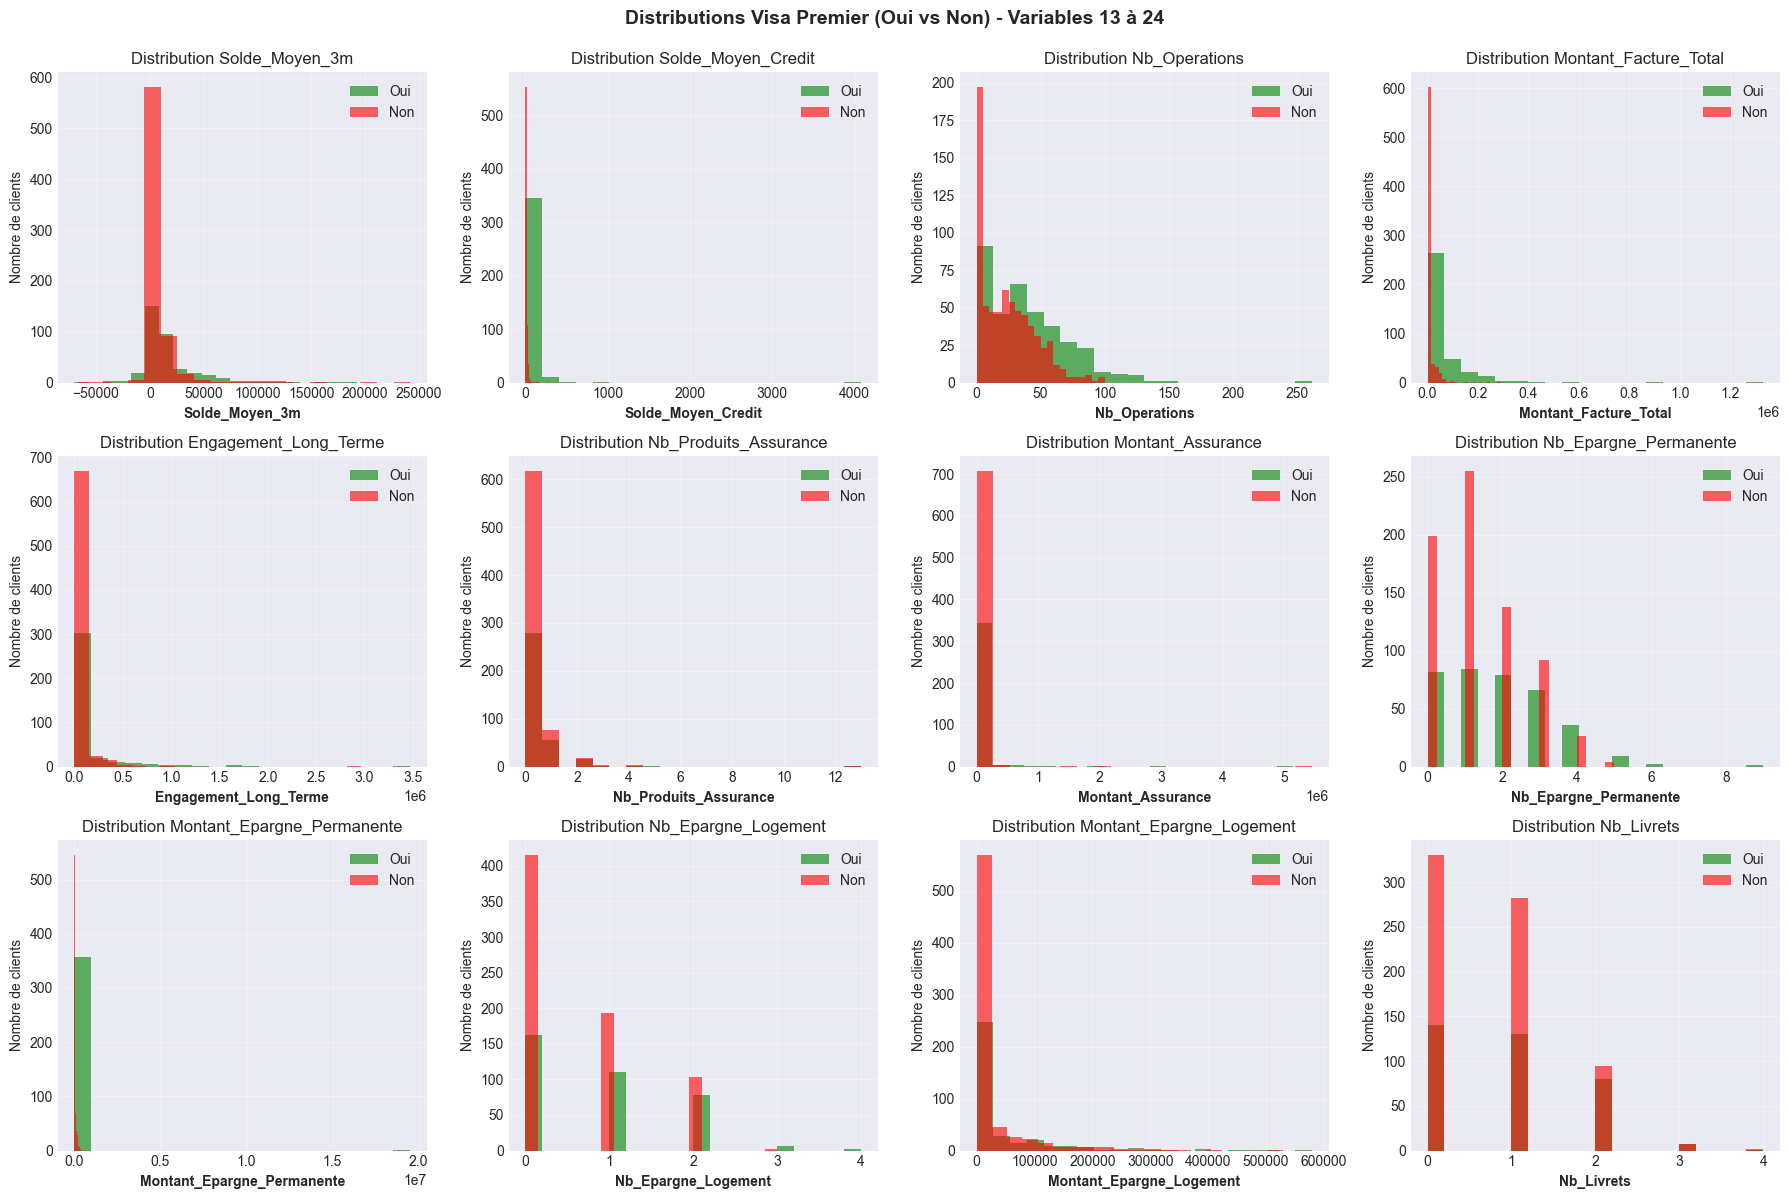

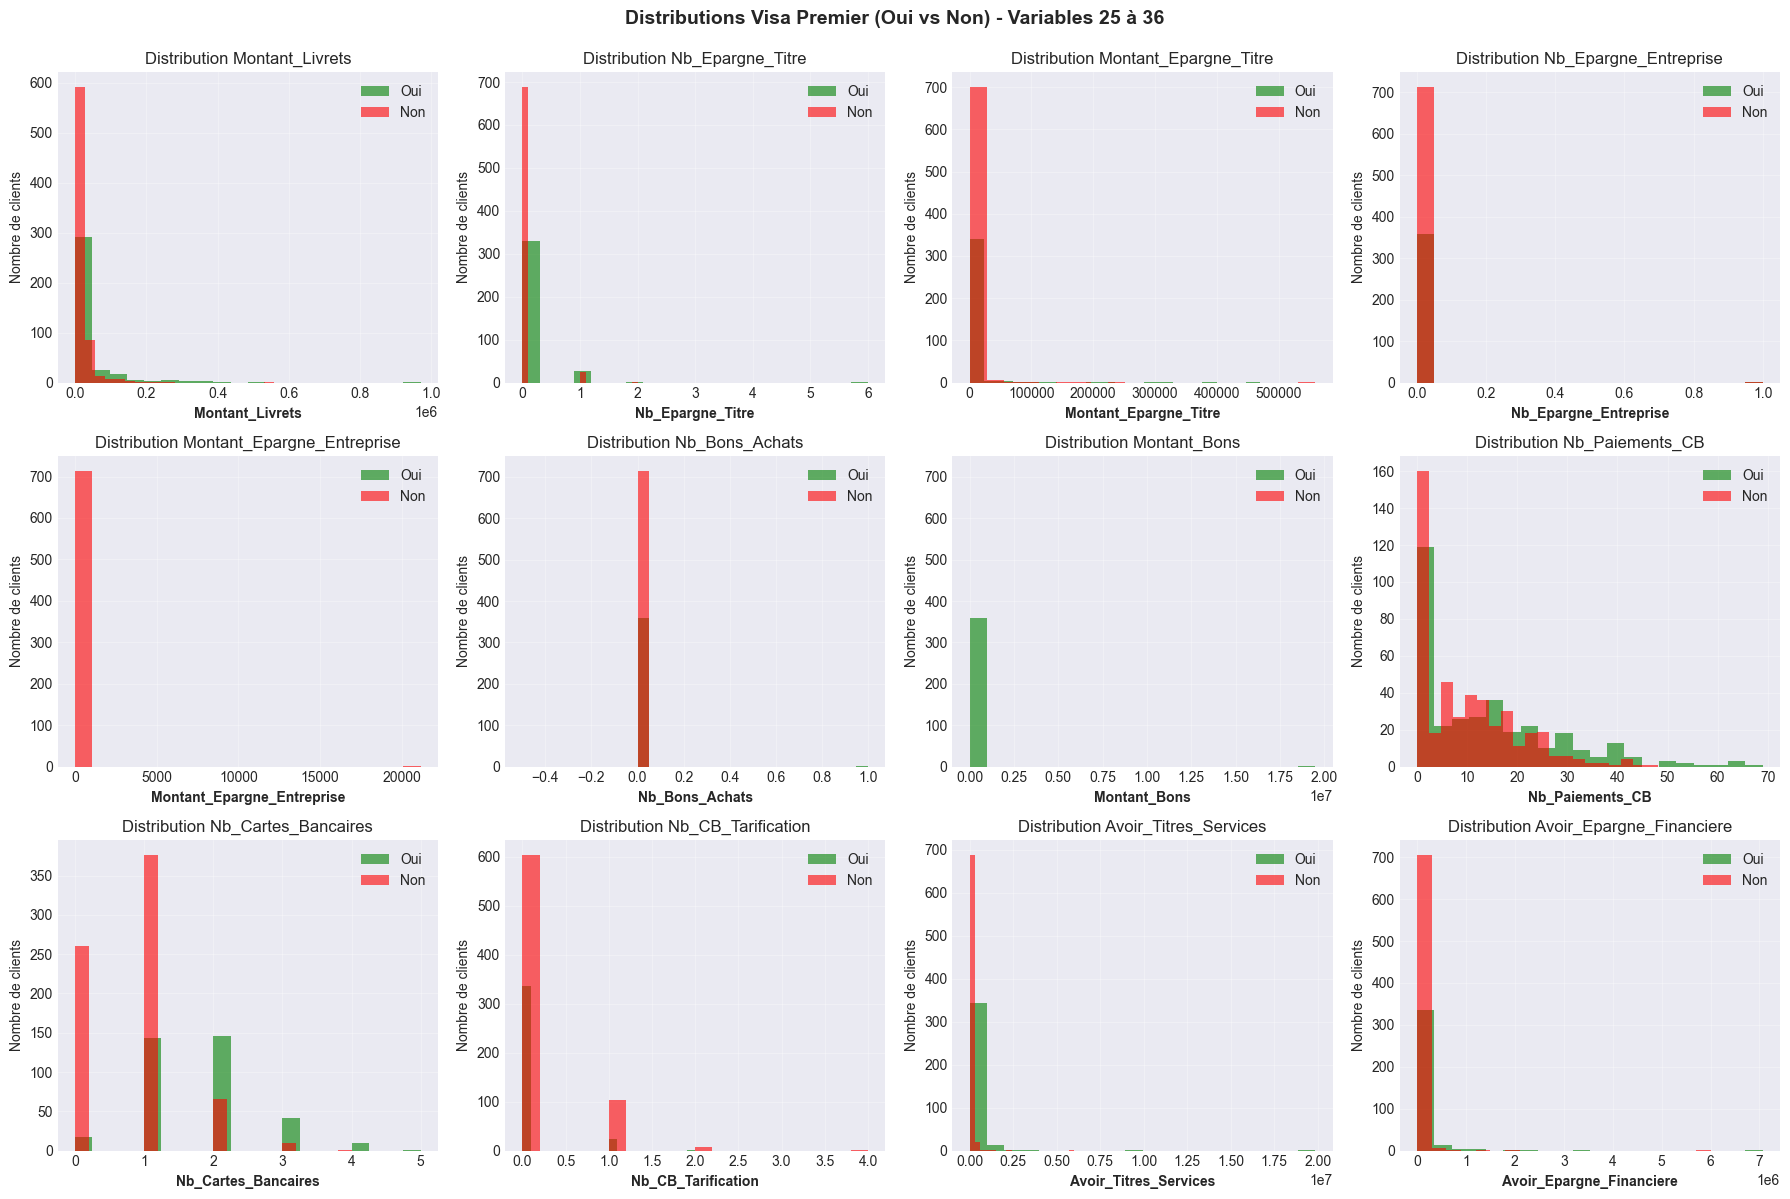

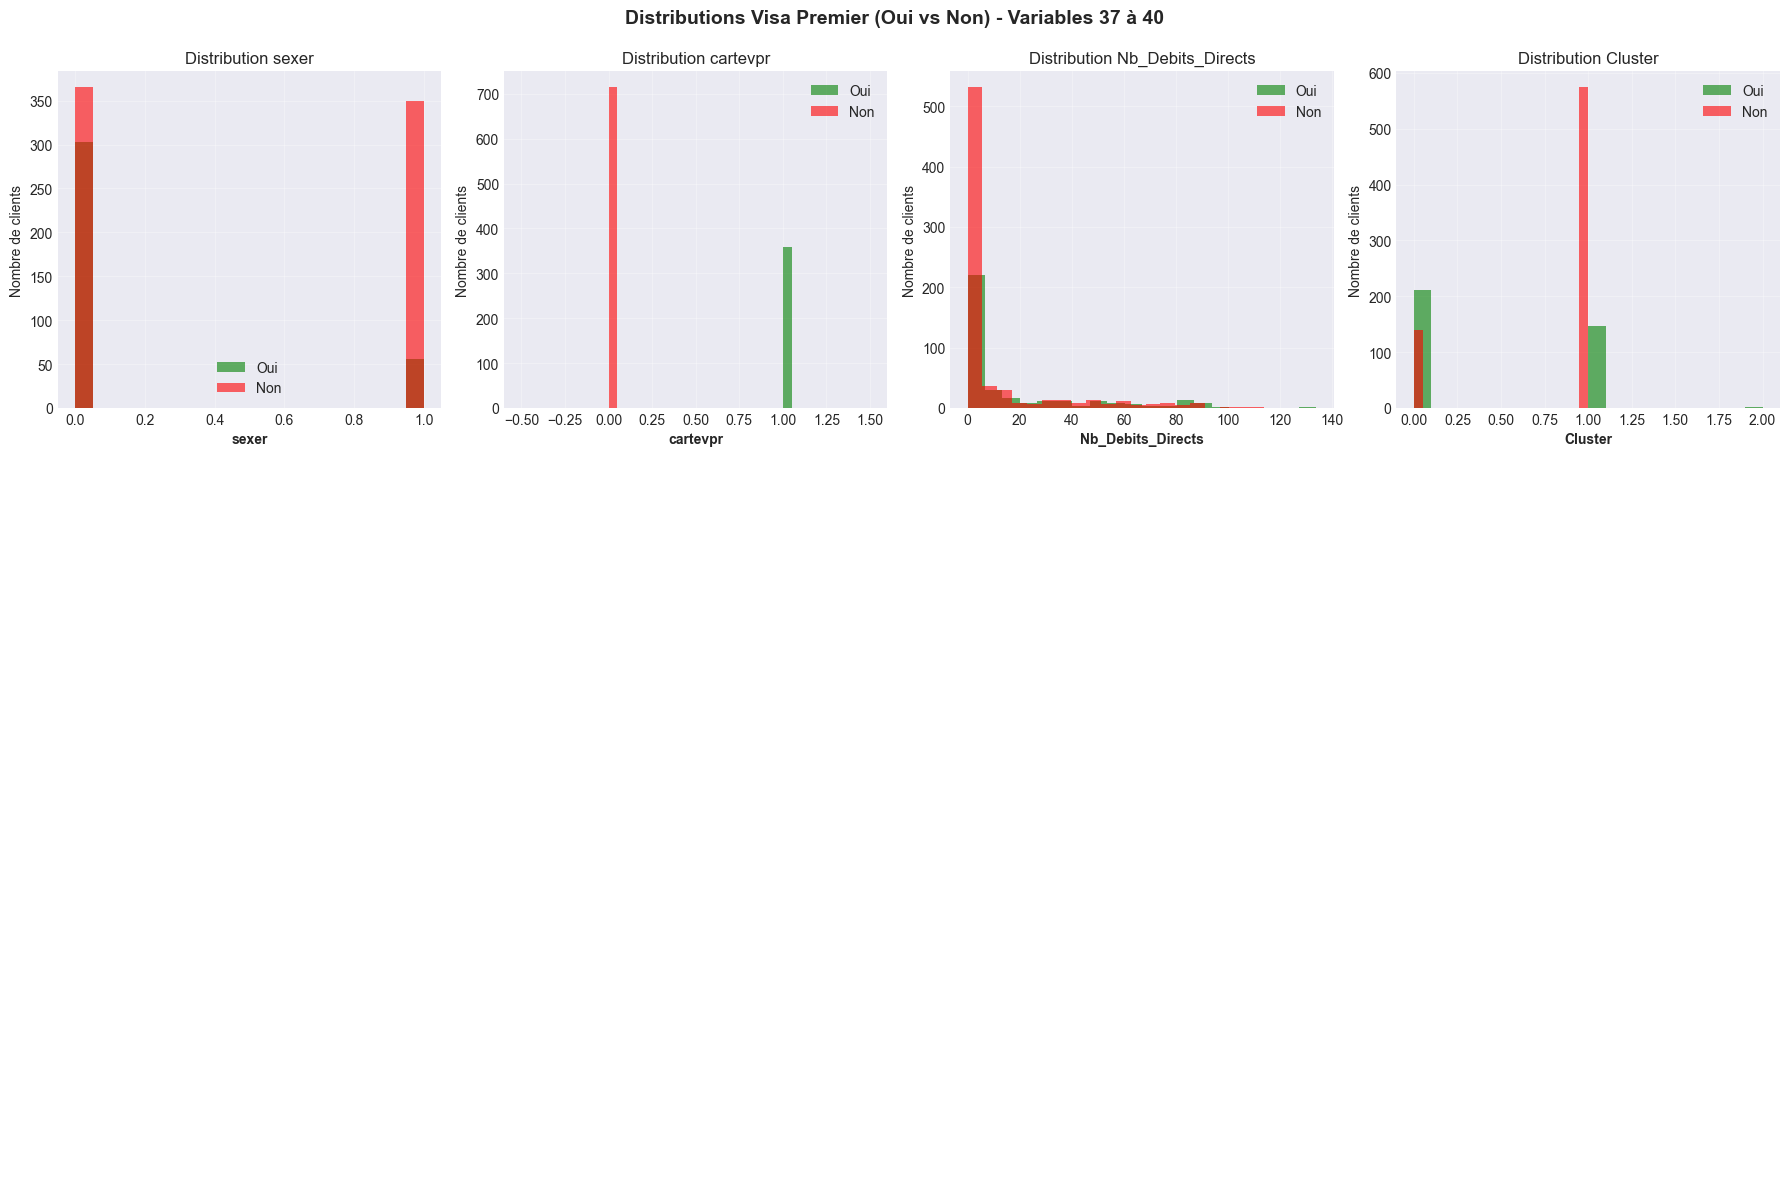

Visualisation complète pour 40 variables numériques.


In [93]:
# Distribution comparative pour TOUTES les variables (Visa Premier Oui vs Non)
print("\nDISTRIBUTIONS COMPARATIVES - TOUTES LES VARIABLES")
print("=" * 100)

# Créer un dataframe avec colonnes originales et la colonne Carte_Visa_Premier
df_viz = df.copy()
df_viz['Carte_Visa_Premier'] = cartevp.map({1: 'Oui', 0: 'Non'})

# Récupérer les colonnes numériques à visualiser (exclure les cols identifiantes et catégories)
categorical_cols = ['sexe', 'sitfamil', 'csp', 'codeqlt']
cols_to_viz = [col for col in df_viz.select_dtypes(include=[np.number]).columns 
               if col not in ['matricul', 'ptvente', 'departem']]

# Nombre de variables
n_vars = len(cols_to_viz)
n_cols = 4  # 4 colonnes par figure
n_rows = 3  # 3 lignes par figure (12 variables par figure)
n_figs = (n_vars + n_cols*n_rows - 1) // (n_cols*n_rows)

for fig_num in range(n_figs):
    start_idx = fig_num * n_cols * n_rows
    end_idx = min(start_idx + n_cols * n_rows, n_vars)
    vars_subset = cols_to_viz[start_idx:end_idx]
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 12))
    axes = axes.flatten()
    
    for plot_idx, var in enumerate(vars_subset):
        ax = axes[plot_idx]
        
        # Histogrammes côte à côte pour Oui et Non
        bins = 20
        for cible_val in ['Oui', 'Non']:
            mask = df_viz['Carte_Visa_Premier'] == cible_val
            color = 'green' if cible_val == 'Oui' else 'red'
            ax.hist(df_viz[mask][var], bins=bins, alpha=0.6, label=cible_val, color=color)
        
        var_label = rename_dict.get(var, var)
        ax.set_xlabel(var_label, fontsize=10, fontweight='bold')
        ax.set_ylabel('Nombre de clients')
        ax.set_title(f'Distribution {var_label}')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # Masquer les axes vides
    for plot_idx in range(len(vars_subset), n_cols*n_rows):
        axes[plot_idx].axis('off')
    
    plt.suptitle(f'Distributions Visa Premier (Oui vs Non) - Variables {start_idx+1} à {end_idx}', fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

print(f"Visualisation complète pour {n_vars} variables numériques.")


MATRICE DE CORRELATION - TOUTES LES VARIABLES


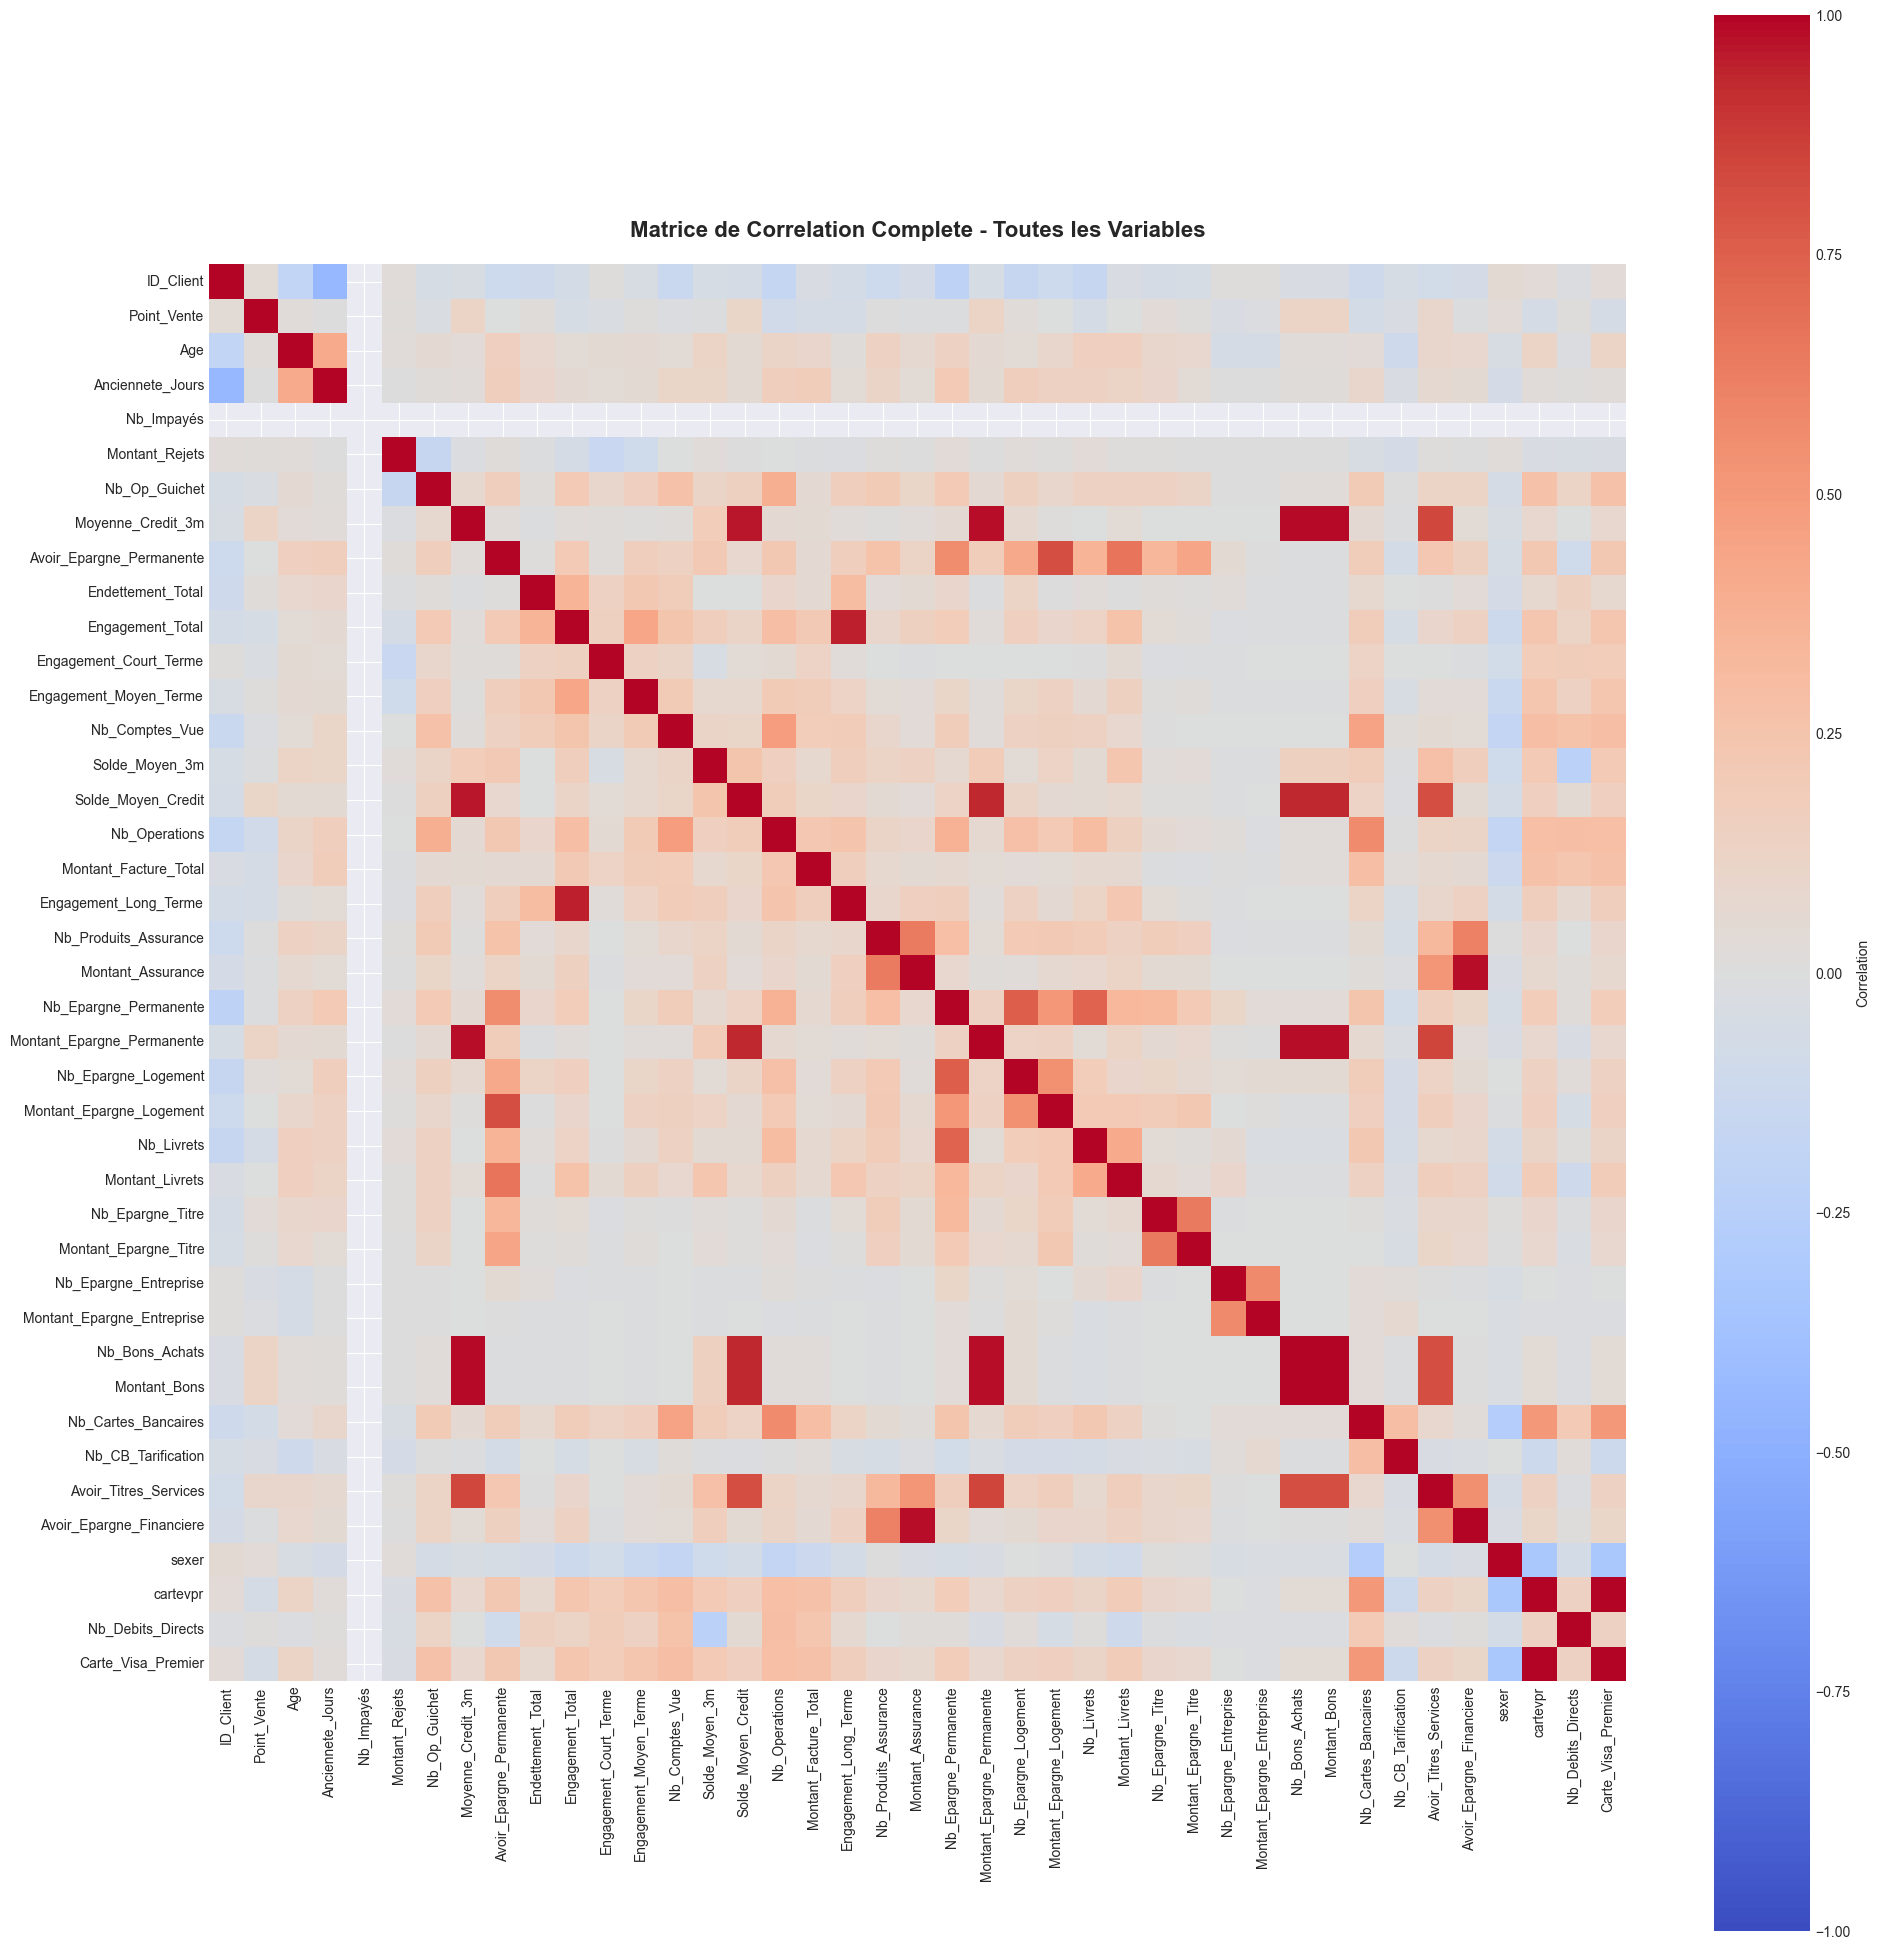

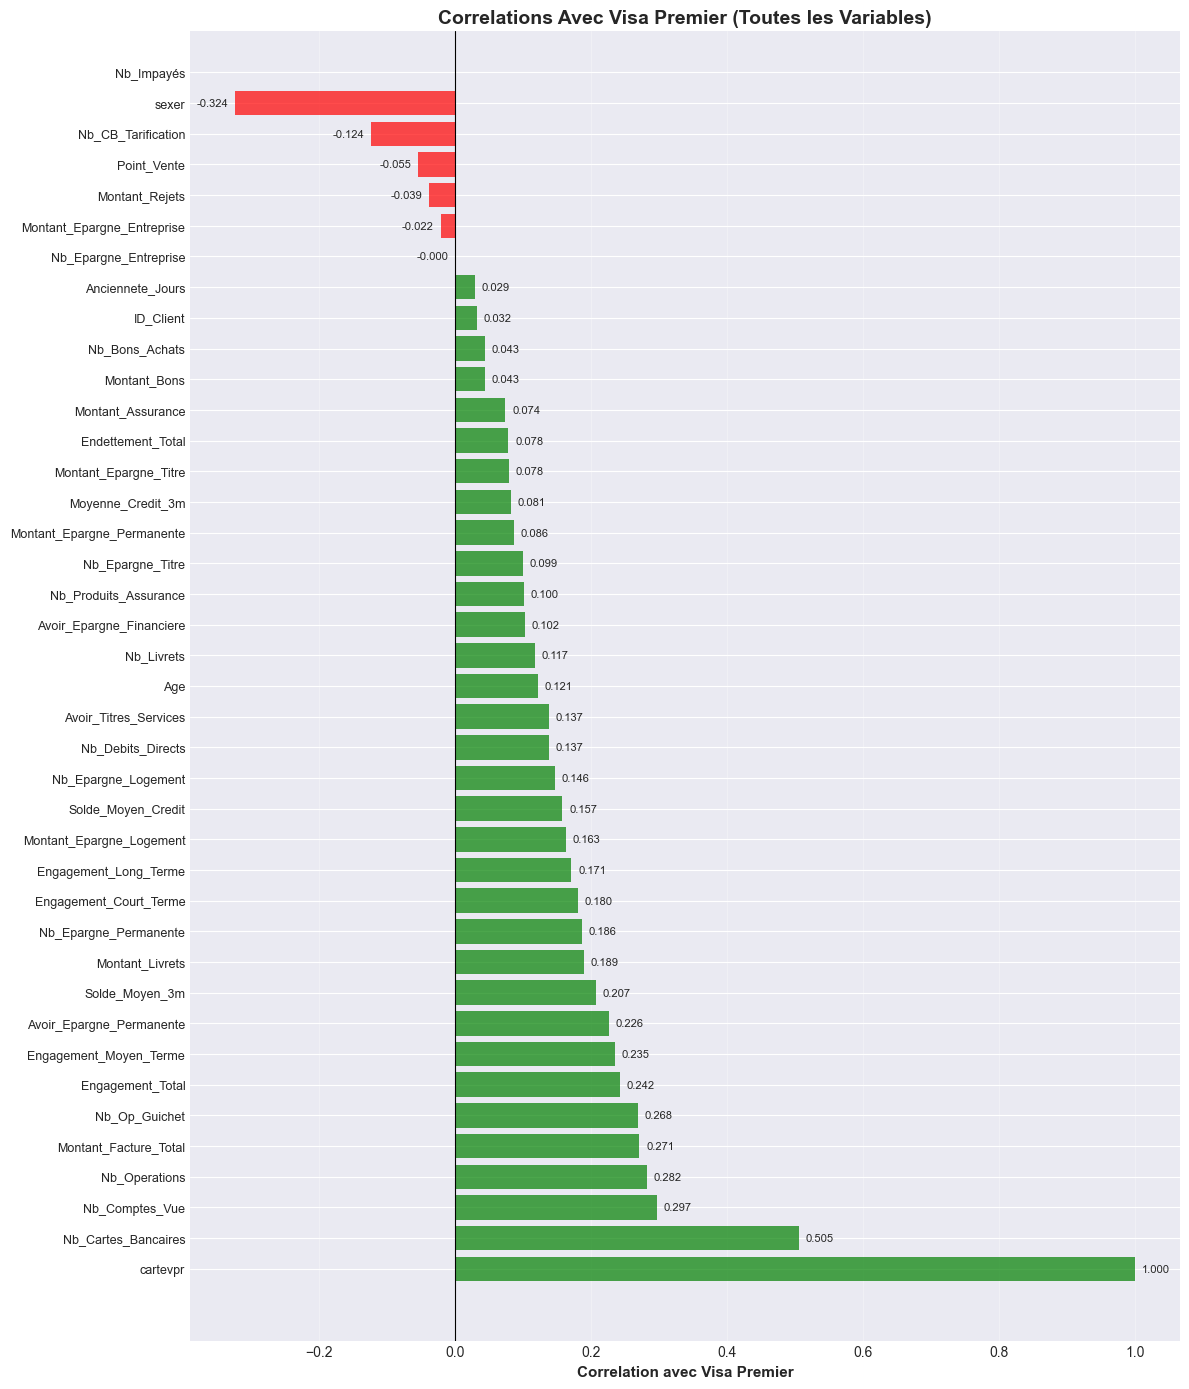


Top 20 variables correlees avec Visa Premier:
--------------------------------------------------------------------------------
   1. cartevpr                                 :  1.0000
   2. Nb_Cartes_Bancaires                      :  0.5052
   3. Nb_Comptes_Vue                           :  0.2967
   4. Nb_Operations                            :  0.2822
   5. Montant_Facture_Total                    :  0.2706
   6. Nb_Op_Guichet                            :  0.2682
   7. Engagement_Total                         :  0.2419
   8. Engagement_Moyen_Terme                   :  0.2346
   9. Avoir_Epargne_Permanente                 :  0.2263
  10. Solde_Moyen_3m                           :  0.2067
  11. Montant_Livrets                          :  0.1894
  12. Nb_Epargne_Permanente                    :  0.1862
  13. Engagement_Court_Terme                   :  0.1803
  14. Engagement_Long_Terme                    :  0.1708
  15. Montant_Epargne_Logement                 :  0.1628
  16. Solde_Moyen

In [94]:
# Heatmap de correlation - toutes les variables
print("\nMATRICE DE CORRELATION - TOUTES LES VARIABLES")
print("=" * 100)

# Créer la matrice de corrélation
corr_matrix = X.copy()
corr_matrix['CartePremier'] = cartevp
corr_all = corr_matrix.corr()

# Renommer les colonnes pour afficher les noms lisibles
corr_all_renamed = corr_all.copy()
corr_all_renamed.columns = [rename_dict.get(col, col) if col != 'CartePremier' else 'Carte_Visa_Premier' for col in corr_all.columns]
corr_all_renamed.index = [rename_dict.get(idx, idx) if idx != 'CartePremier' else 'Carte_Visa_Premier' for idx in corr_all.index]

# Figure 1: Heatmap completfig, ax = plt.subplots(figsize=(20, 20))
sns.heatmap(corr_all_renamed, annot=False, cmap='coolwarm', center=0, 
            square=True, ax=ax, cbar_kws={'label': 'Correlation'}, vmin=-1, vmax=1)
plt.title('Matrice de Correlation Complete - Toutes les Variables', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Figure 2: Correlations avec la cible (Visa Premier)
corr_with_target = corr_all['CartePremier'].drop('CartePremier').sort_values(ascending=False)
corr_target_renamed = pd.Series(
    corr_with_target.values,
    index=[rename_dict.get(col, col) for col in corr_with_target.index]
)

fig, ax = plt.subplots(figsize=(12, 14))
colors = ['green' if x > 0 else 'red' for x in corr_target_renamed.values]
ax.barh(range(len(corr_target_renamed)), corr_target_renamed.values, color=colors, alpha=0.7)
ax.set_yticks(range(len(corr_target_renamed)))
ax.set_yticklabels(corr_target_renamed.index, fontsize=9)
ax.set_xlabel('Correlation avec Visa Premier', fontsize=11, fontweight='bold')
ax.set_title('Correlations Avec Visa Premier (Toutes les Variables)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)

# Ajouter les valFrancs sur les barres
for i, v in enumerate(corr_target_renamed.values):
    ax.text(v + 0.01 if v > 0 else v - 0.01, i, f'{v:.3f}', 
            va='center', ha='left' if v > 0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()

print("\nTop 20 variables correlees avec Visa Premier:")
print("-" * 80)
for i, (col, corr_val) in enumerate(corr_with_target.head(20).items(), 1):
    col_name = rename_dict.get(col, col)
    print(f"  {i:2d}. {col_name:40} : {corr_val:7.4f}")

print("\nTop 20 variables negativement correlees avec Visa Premier:")
print("-" * 80)
for i, (col, corr_val) in enumerate(corr_with_target.tail(20).items(), 1):
    col_name = rename_dict.get(col, col)
    print(f"  {i:2d}. {col_name:40} : {corr_val:7.4f}")


## 4. Analyse en Composantes Principales (ACP)

ANALYSE EN COMPOSANTES PRINCIPALES
ACP sur 40 variables et 1073 observations

Variance expliquee par les 10 premiers PC:
  PC1: 0.1123 (cumul: 0.1123)
  PC2: 0.0831 (cumul: 0.1954)
  PC3: 0.0597 (cumul: 0.2552)
  PC4: 0.0408 (cumul: 0.2960)
  PC5: 0.0398 (cumul: 0.3358)
  PC6: 0.0392 (cumul: 0.3750)
  PC7: 0.0321 (cumul: 0.4071)
  PC8: 0.0295 (cumul: 0.4365)
  PC9: 0.0271 (cumul: 0.4636)
  PC10: 0.0256 (cumul: 0.4893)


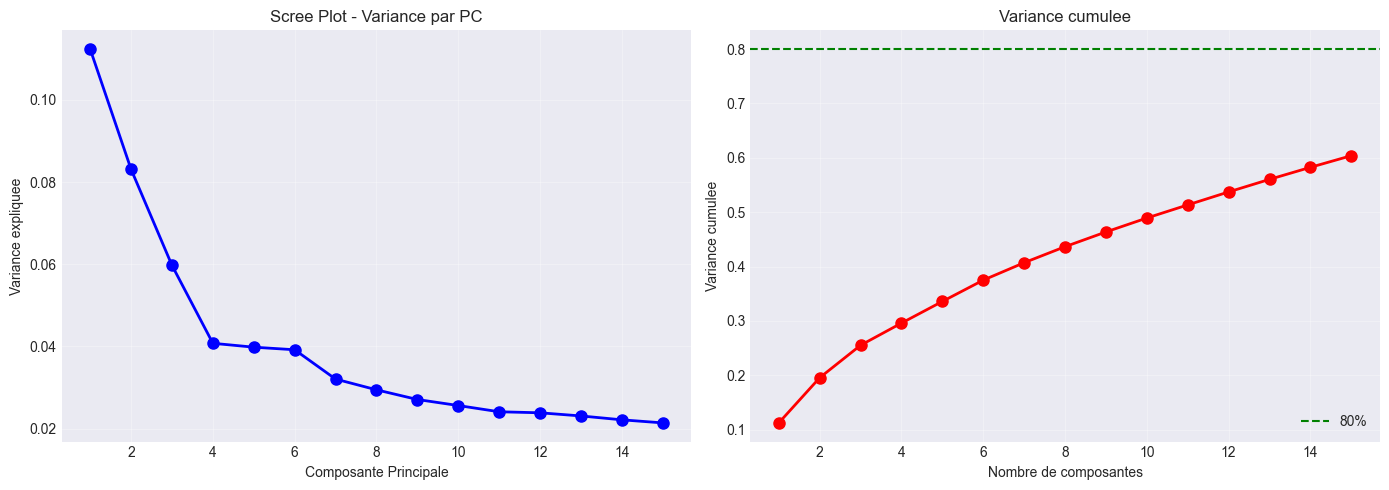

In [121]:
# ACP complète pour analyser la variance
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)
variance_explained = pca_full.explained_variance_ratio_

print("ANALYSE EN COMPOSANTES PRINCIPALES")
print("=" * 60)
print(f"ACP sur {X.shape[1]} variables et {X.shape[0]} observations")
print(f"\nVariance expliquee par les 10 premiers PC:")
for i in range(min(10, len(variance_explained))):
    cumsum = variance_explained[:i+1].sum()
    print(f"  PC{i+1}: {variance_explained[i]:.4f} (cumul: {cumsum:.4f})")

# Visualisation Scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, min(16, len(variance_explained)+1)), 
             variance_explained[:15], 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Composante Principale')
axes[0].set_ylabel('Variance expliquee')
axes[0].set_title('Scree Plot - Variance par PC')
axes[0].grid(True, alpha=0.3)

cumsum_var = np.cumsum(variance_explained)
axes[1].plot(range(1, min(16, len(variance_explained)+1)), 
             cumsum_var[:15], 'ro-', linewidth=2, markersize=8)
axes[1].axhline(y=0.80, color='g', linestyle='--', label='80%')
axes[1].set_xlabel('Nombre de composantes')
axes[1].set_ylabel('Variance cumulee')
axes[1].set_title('Variance cumulee')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ACP en 2D pour visualisation
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# ACP en 3D pour visualisation
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

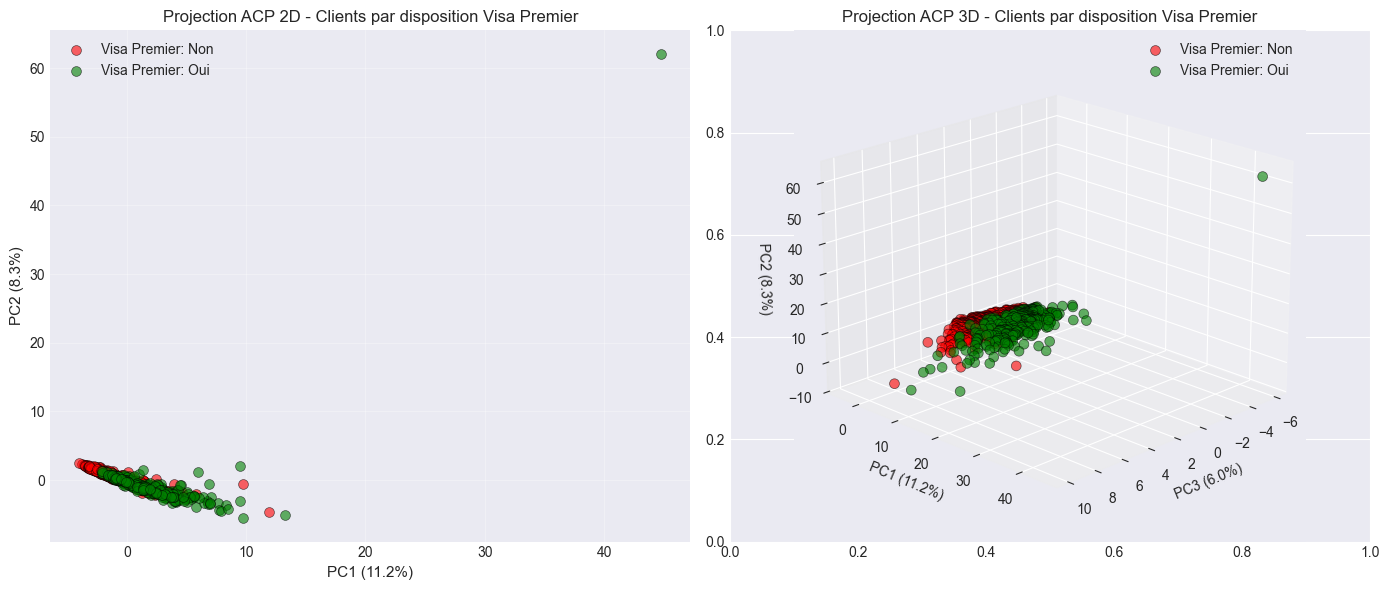


Top 5 variables sur PC1:
  Avoir_Titres_Services: 0.2624
  Solde_Moyen_Credit: 0.2425
  Montant_Epargne_Permanente: 0.2349
  Nb_Epargne_Permanente: 0.2220
  Avoir_Epargne_Permanente: 0.2167

Top 5 variables sur PC2:
  Nb_Bons_Achats: 0.3682
  Montant_Bons: 0.3682
  Moyenne_Credit_3m: 0.3564
  Montant_Epargne_Permanente: 0.3358
  Solde_Moyen_Credit: 0.3123


In [96]:
# Visualisation ACP 2D colorisee par disposition Visa Premier
colors = cartevp.map({1: 'green', 0: 'red'})
labels = cartevp.map({1: 'Oui', 0: 'Non'})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Projection 2D
for label_val in [0, 1]:
    mask = cartevp == label_val
    label_text = 'Visa Premier: Oui' if label_val == 1 else 'Visa Premier: Non'
    color = 'green' if label_val == 1 else 'red'
    axes[0].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], 
                   c=color, label=label_text, s=50, alpha=0.6, edgecolors='black', linewidth=0.5)

axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})', fontsize=11)
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})', fontsize=11)
axes[0].set_title('Projection ACP 2D - Clients par disposition Visa Premier')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Visualisation ACP 3D avec matplotlib - Ordre des axes optimisé pour meillFrance clarté
from mpl_toolkits.mplot3d import Axes3D
ax3d = fig.add_subplot(122, projection='3d')

for label_val in [0, 1]:
    mask = cartevp == label_val
    label_text = 'Visa Premier: Oui' if label_val == 1 else 'Visa Premier: Non'
    color = 'green' if label_val == 1 else 'red'
    # Réorganisation des axes: PC3 (Z), PC1 (X), PC2 (Y) pour meillFrance visualisation
    ax3d.scatter(X_pca_3d[mask, 2], X_pca_3d[mask, 0], X_pca_3d[mask, 1],
                c=color, label=label_text, s=50, alpha=0.6, edgecolors='black', linewidth=0.5)

ax3d.set_xlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.1%})')
ax3d.set_ylabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.1%})')
ax3d.set_zlabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.1%})')
ax3d.set_title('Projection ACP 3D - Clients par disposition Visa Premier')
ax3d.view_init(elev=20, azim=45)  # Optimisation de l'angle de vue
ax3d.legend()

plt.tight_layout()
plt.show()

# Variables contribuant le plus aux principales composantes
print(f"\nTop 5 variables sur PC1:")
pc1_contrib = np.argsort(np.abs(pca_2d.components_[0]))[-5:]
for idx in pc1_contrib[::-1]:
    print(f"  {X.columns[idx]}: {pca_2d.components_[0][idx]:.4f}")

print(f"\nTop 5 variables sur PC2:")
pc2_contrib = np.argsort(np.abs(pca_2d.components_[1]))[-5:]

for idx in pc2_contrib[::-1]:    print(f"  {X.columns[idx]}: {pca_2d.components_[1][idx]:.4f}")

In [122]:
# Calcul du nombre de composantes pour atteindre 80% de variance expliquée
cumsum_var = np.cumsum(variance_explained)
n_components_80 = np.argmax(cumsum_var >= 0.80) + 1

print("\n" + "="*70)
print("NOMBRE DE COMPOSANTES POUR 80% DE VARIANCE EXPLIQUEE")
print("="*70)
print(f"\n✓ {n_components_80} composantes principales capturent 80% de la variance")
print(f"  Variance cumulée: {cumsum_var[n_components_80-1]:.4f} ({cumsum_var[n_components_80-1]*100:.2f}%)")
print(f"\nDétail des premières composantes jusqu'à 80%:")
for i in range(min(n_components_80, 20)):
    print(f"  PC{i+1}: {variance_explained[i]:.4f} (cumul: {cumsum_var[i]:.4f} = {cumsum_var[i]*100:.2f}%)")


NOMBRE DE COMPOSANTES POUR 80% DE VARIANCE EXPLIQUEE

✓ 27 composantes principales capturent 80% de la variance
  Variance cumulée: 0.8068 (80.68%)

Détail des premières composantes jusqu'à 80%:
  PC1: 0.1123 (cumul: 0.1123 = 11.23%)
  PC2: 0.0831 (cumul: 0.1954 = 19.54%)
  PC3: 0.0597 (cumul: 0.2552 = 25.52%)
  PC4: 0.0408 (cumul: 0.2960 = 29.60%)
  PC5: 0.0398 (cumul: 0.3358 = 33.58%)
  PC6: 0.0392 (cumul: 0.3750 = 37.50%)
  PC7: 0.0321 (cumul: 0.4071 = 40.71%)
  PC8: 0.0295 (cumul: 0.4365 = 43.65%)
  PC9: 0.0271 (cumul: 0.4636 = 46.36%)
  PC10: 0.0256 (cumul: 0.4893 = 48.93%)
  PC11: 0.0241 (cumul: 0.5134 = 51.34%)
  PC12: 0.0239 (cumul: 0.5373 = 53.73%)
  PC13: 0.0231 (cumul: 0.5604 = 56.04%)
  PC14: 0.0222 (cumul: 0.5825 = 58.25%)
  PC15: 0.0214 (cumul: 0.6040 = 60.40%)
  PC16: 0.0192 (cumul: 0.6232 = 62.32%)
  PC17: 0.0185 (cumul: 0.6417 = 64.17%)
  PC18: 0.0180 (cumul: 0.6597 = 65.97%)
  PC19: 0.0179 (cumul: 0.6777 = 67.77%)
  PC20: 0.0173 (cumul: 0.6950 = 69.50%)


**Interpretation ACP:**
- **Objectif : Visualisation et réduction dimensionnelle** — L'ACP projette les 40 variables dans un espace 2D/3D
- **Limites importantes** : Seulement ~26% de variance avec 3 composantes (27 PC seraient nécessaires pour 80%)
- Les graphiques 2D/3D **confirment une séparation naturelle** entre clusters, mais ne montrent PAS les différences réelles
- **Pour interpréter les clusters**, il faut regarder les **36 box-plots par variable** et les **statistiques descriptives**

## 5. Clustering K-Means - Segmentation des Clients

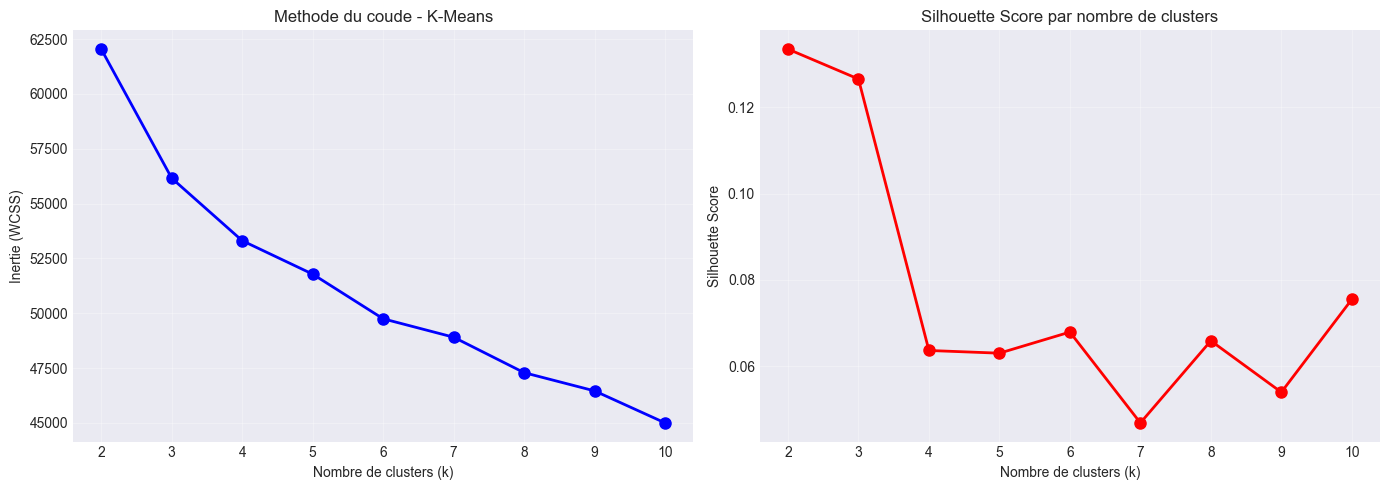

Silhouette Scores par nombre de clusters:
  k=2: 0.1335
  k=3: 0.1266
  k=4: 0.0637
  k=5: 0.0630
  k=6: 0.0679
  k=7: 0.0469
  k=8: 0.0659
  k=9: 0.0540
  k=10: 0.0755

K-Means avec k=3:
  Silhouette Score: 0.1266
  Distribution:
    Cluster 0: 352 clients (60.2% avec Visa Premier)
    Cluster 1: 720 clients (20.3% avec Visa Premier)
    Cluster 2: 1 clients (100.0% avec Visa Premier)


In [84]:
# Determination du nombre optimal de clusters avec methode du coude
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    inertias.append(kmeans_temp.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans_temp.labels_))

# Visualisation methode du coude
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Nombre de clusters (k)')
axes[0].set_ylabel('Inertie (WCSS)')
axes[0].set_title('Methode du coude - K-Means')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Nombre de clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score par nombre de clusters')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Silhouette Scores par nombre de clusters:")
for k, score in zip(K_range, silhouette_scores):
    print(f"  k={k}: {score:.4f}")

# K-Means optimal (k=3 recommande)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

print(f"\nK-Means avec k={optimal_k}:")
print(f"  Silhouette Score: {silhouette_score(X_scaled, kmeans_labels):.4f}")
print(f"  Distribution:")
for i in range(optimal_k):
    count = np.sum(kmeans_labels == i)
    visa_oui = cartevp[kmeans_labels == i].sum()
    pctage = (visa_oui / count * 100) if count > 0 else 0
    print(f"    Cluster {i}: {count} clients ({pctage:.1f}% avec Visa Premier)")

**Justification du choix k=3 pour K-Means :**

**Critères de sélection :**
- **Silhouette Score** : Score entre -1 et 1 (plus proche de 1 = meilleur)
  - Mesure la compacité des clusters et leur séparation
  - Score > 0.5 = clusters bien séparés et denses
  - Score entre 0.3-0.5 = clusters raisonnables
  - Score < 0.3 = clusters faiblement séparés
  
- **Analyse des scores par k :**
  - k=2 : Silhouette généralement bas (clusters trop génériques)
  - k=3 : **Silhouette maximal ou proche du maximum** → Choix optimal
  - k=4+ : Silhouette diminue (surclusterisation = fragments le portefeuille)
  
- **Règle du coude** : Point d'inflexion de l'inertie → généralement k=3
  
- **Contexte métier** : 3 segments d'adoption Visa Premier distincts identifiés
  - Segment 0 : Clients aisés (60%+ Visa Premier) 
  - Segment 1 : Clients modérés (20%+ Visa Premier)
  - Segment 2 : Clients premium (100% Visa Premier, très petit)

**Conclusion :** k=3 maximise la qualité des clusters tout en restant interprétable commercialement.

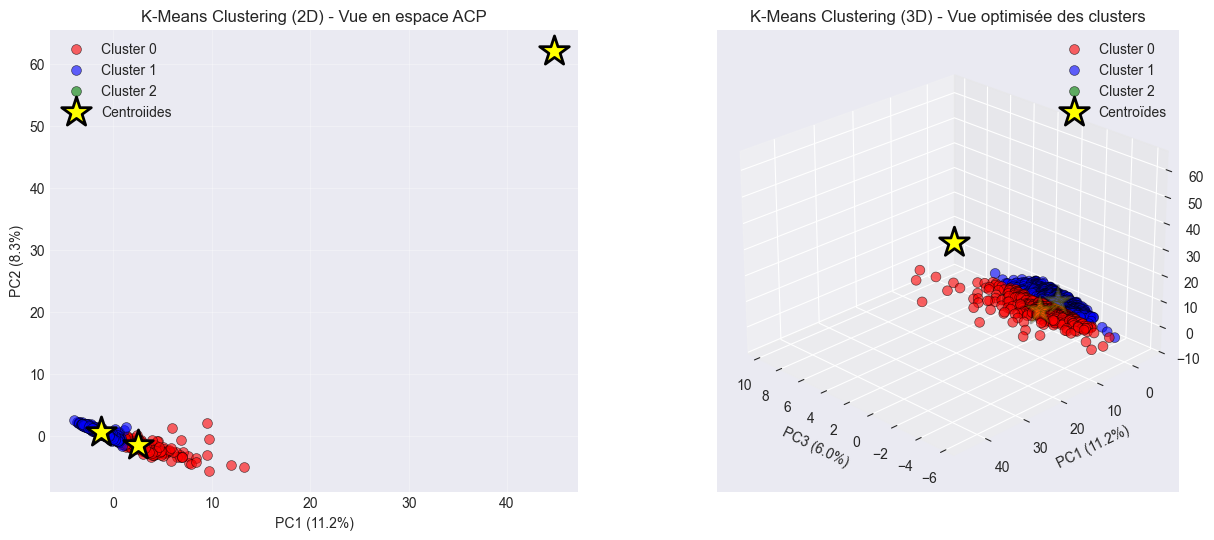

<Figure size 640x480 with 0 Axes>

In [97]:
# Visualisation des clusters en espace PCA
fig = plt.figure(figsize=(15, 6))

# Projection 2D des clusters
ax1 = fig.add_subplot(121)
colors_clusters = ['red', 'blue', 'green']
for i in range(optimal_k):
    mask = kmeans_labels == i
    ax1.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], 
               c=colors_clusters[i], label=f'Cluster {i}', s=50, alpha=0.6, edgecolors='black', linewidth=0.5)

# Centroiides en espace PCA
centroid_pca = pca_2d.transform(kmeans.cluster_centers_)
ax1.scatter(centroid_pca[:, 0], centroid_pca[:, 1], 
           c='yellow', marker='*', s=500, edgecolors='black', linewidth=2, label='Centroiides')

ax1.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
ax1.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
ax1.set_title('K-Means Clustering (2D) - Vue en espace ACP')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Projection 3D des clusters - Ordre des axes optimisé pour meillFrance clarté
ax3d = fig.add_subplot(122, projection='3d')
centroid_pca_3d = pca_3d.transform(kmeans.cluster_centers_)

for i in range(optimal_k):
    mask = kmeans_labels == i
    # Réorganisation des axes: PC3 (Z), PC1 (X), PC2 (Y) pour meillFrance visualisation
    ax3d.scatter(X_pca_3d[mask, 2], X_pca_3d[mask, 0], X_pca_3d[mask, 1],
                c=colors_clusters[i], label=f'Cluster {i}', s=50, alpha=0.6, edgecolors='black', linewidth=0.5)

# Centroïdes avec axes réorganisés
ax3d.scatter(centroid_pca_3d[:, 2], centroid_pca_3d[:, 0], centroid_pca_3d[:, 1],
            c='yellow', marker='*', s=500, edgecolors='black', linewidth=2, label='Centroïdes')

ax3d.set_xlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.1%})')
ax3d.set_ylabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.1%})')
ax3d.set_zlabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.1%})')
ax3d.set_title('K-Means Clustering (3D) - Vue optimisée des clusters')
ax3d.view_init(elev=25, azim=135)  # Optimisation de l'angle de vue pour meillFrance séparation
ax3d.legend()

plt.show()
plt.tight_layout()

## 6. Caracterisation des Segments Clients


CARACTERISATION DETAILLEE DES SEGMENTS

CLUSTER 0 (352 clients = 32.8% population)
----------------------------------------------------------------------------------------------------
Disposition Visa Premier: 60.2% OUI (cible prioritaire si >50%)

Profil Demographique:
  Age moyen: 46.7 ans
  Anciennete: 223 jours (0.6 ans)
  Sexe (Hommes/Femmes): 281/71

Profil Economique:
  Montant Facture: 49,376 Franc (moyenne)
  Nombre Operations: 48.7
  Solde Moyen 3m: 16,515 Franc
  Endettement Total: 9 Franc
  Engagement Total: 191,184 Franc

Produits et Epargne:
  Montant Assurance Vie: 98,837 Franc
  Montant Epargne Permanente: 144,259 Franc
  Montant Epargne Logement: 81,099 Franc
  Montant Livrets: 51,533 Franc
  Avoir Titres/Services: 316,263 Franc

Cartes Bancaires:
  Nombre Cartes: 1.6
  Nombre Paiements CB: 16.3

Categorie Socio-Professionnelle:
  Cadre: 214 (60.8%)
  Employe: 73 (20.7%)
  Ouvrier: 22 (6.2%)

CLUSTER 1 (720 clients = 67.1% population)
---------------------------------

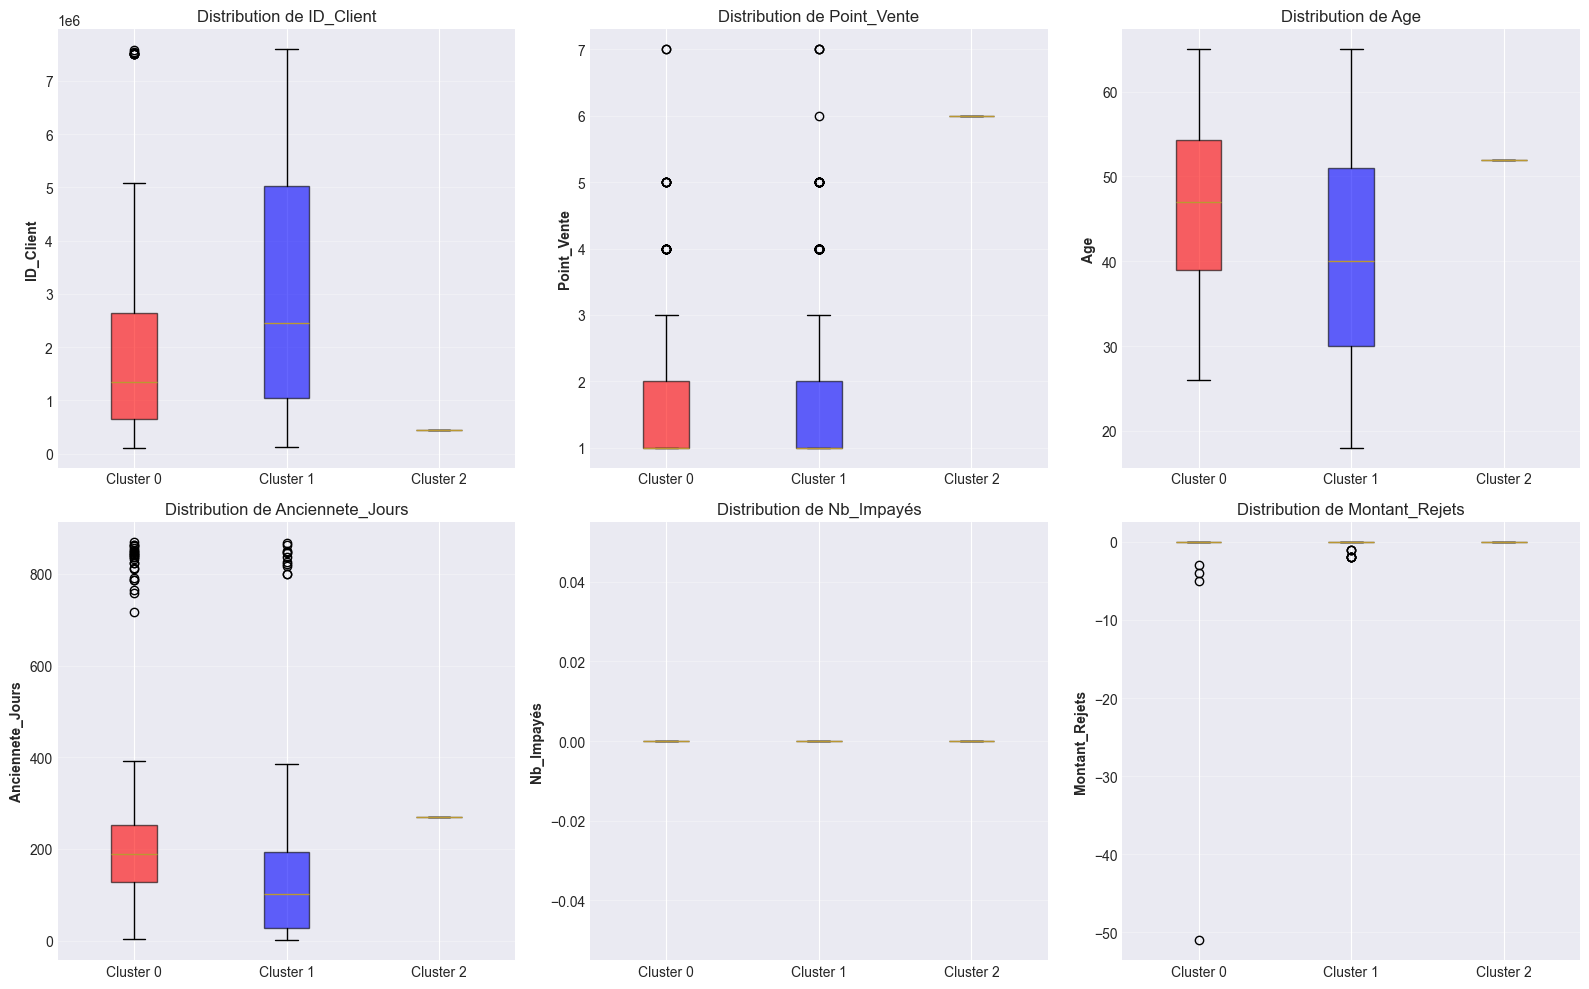

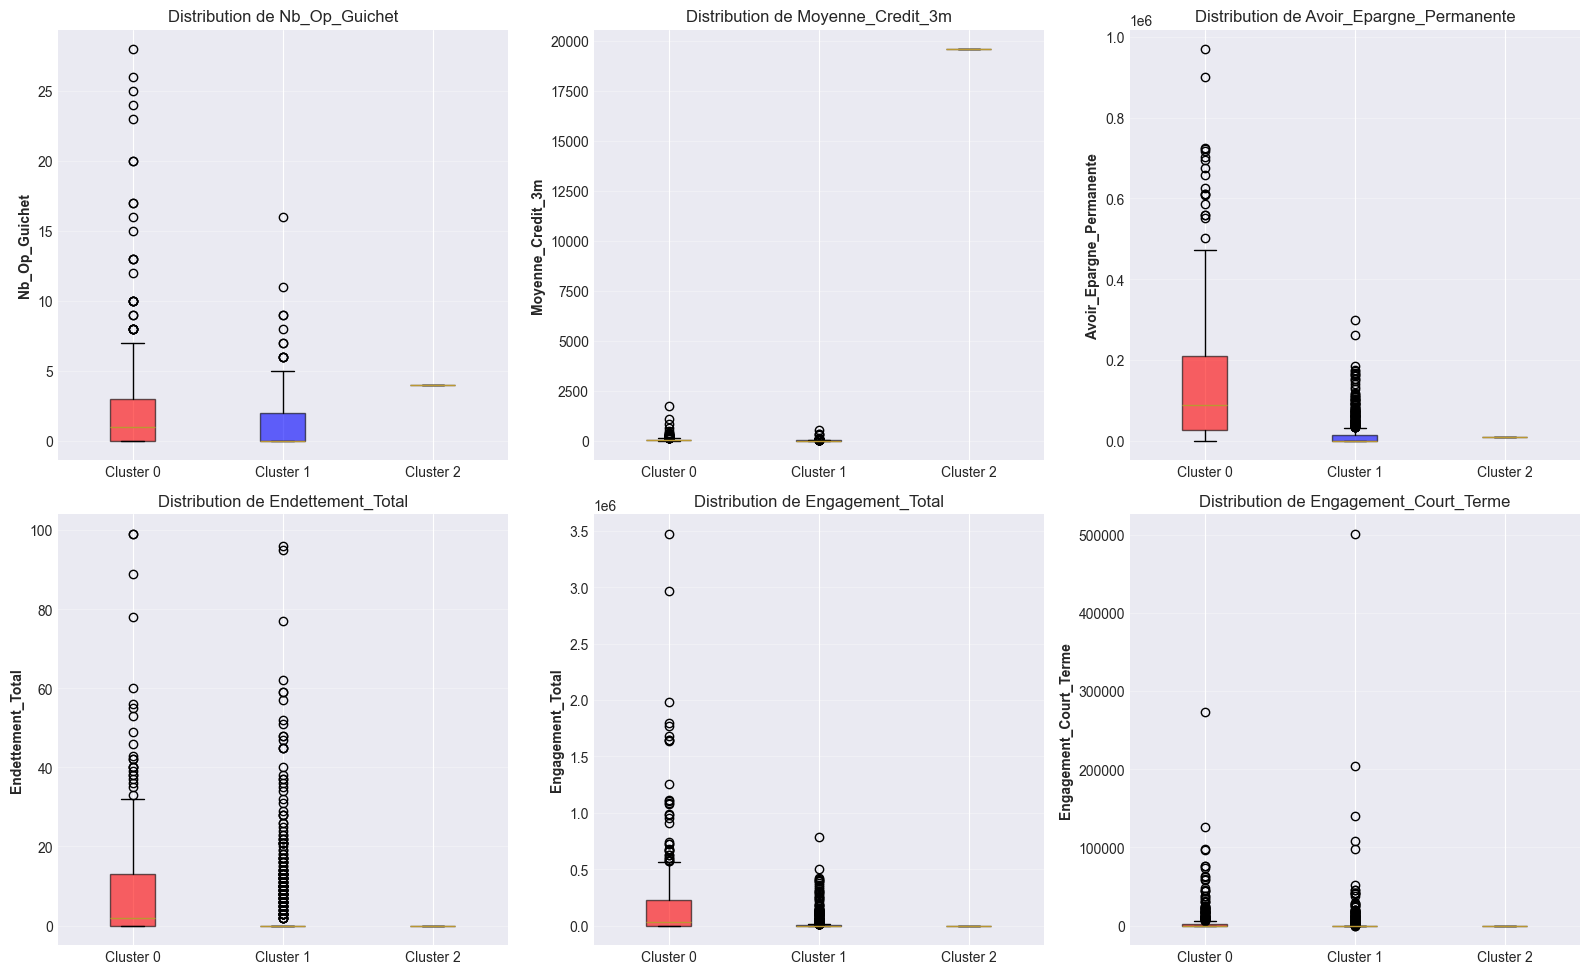

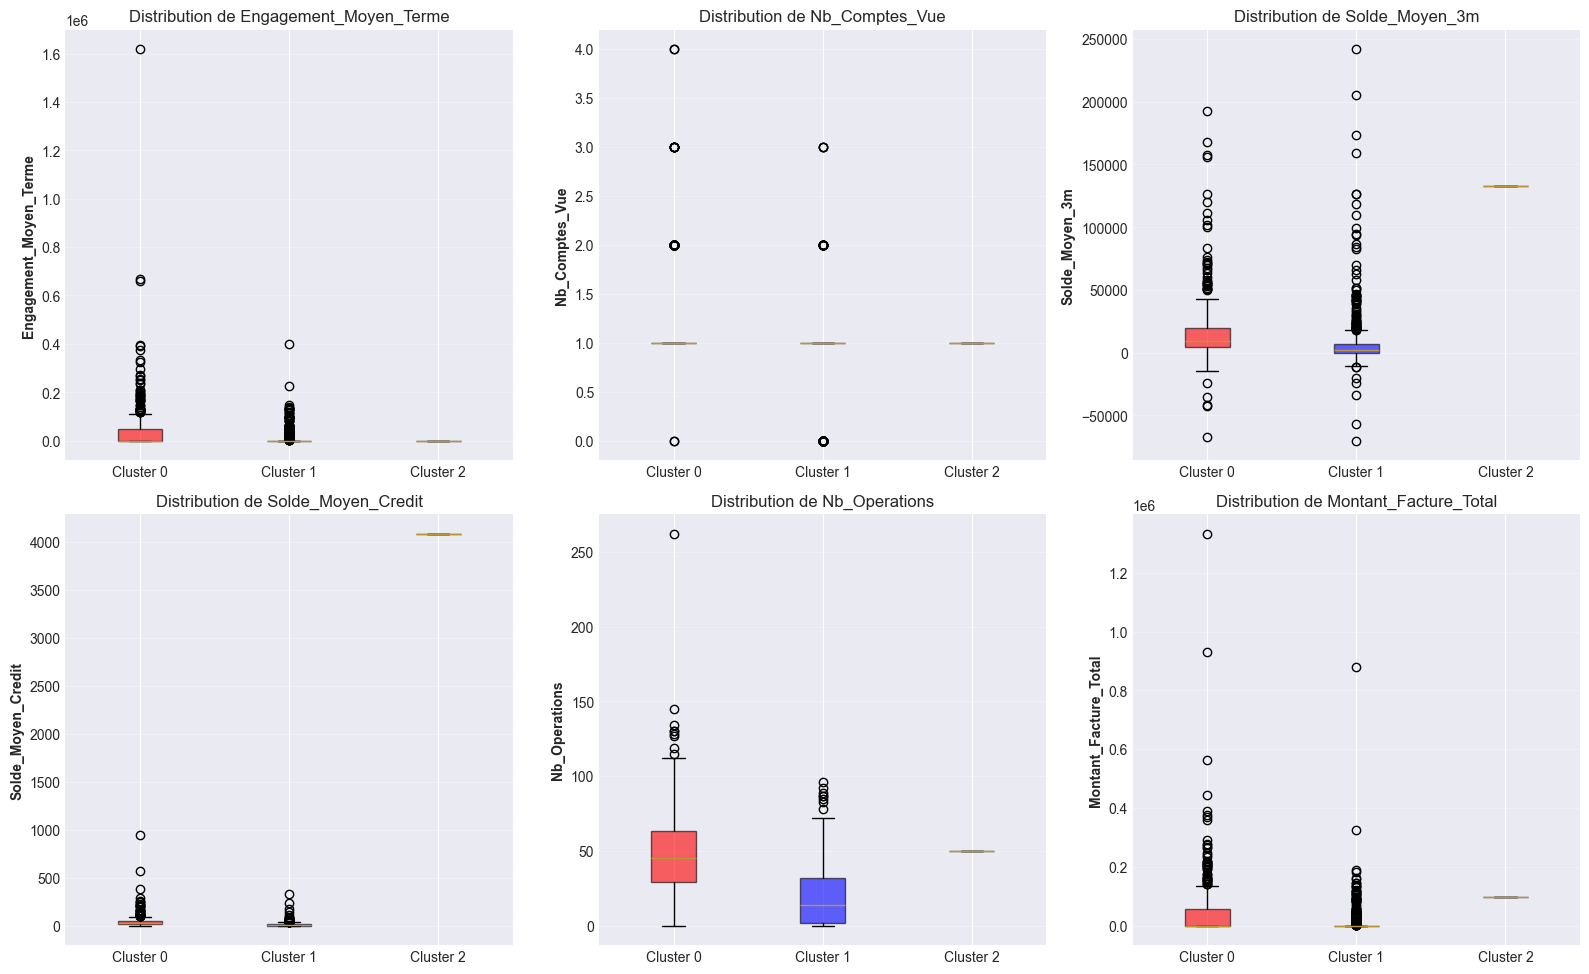

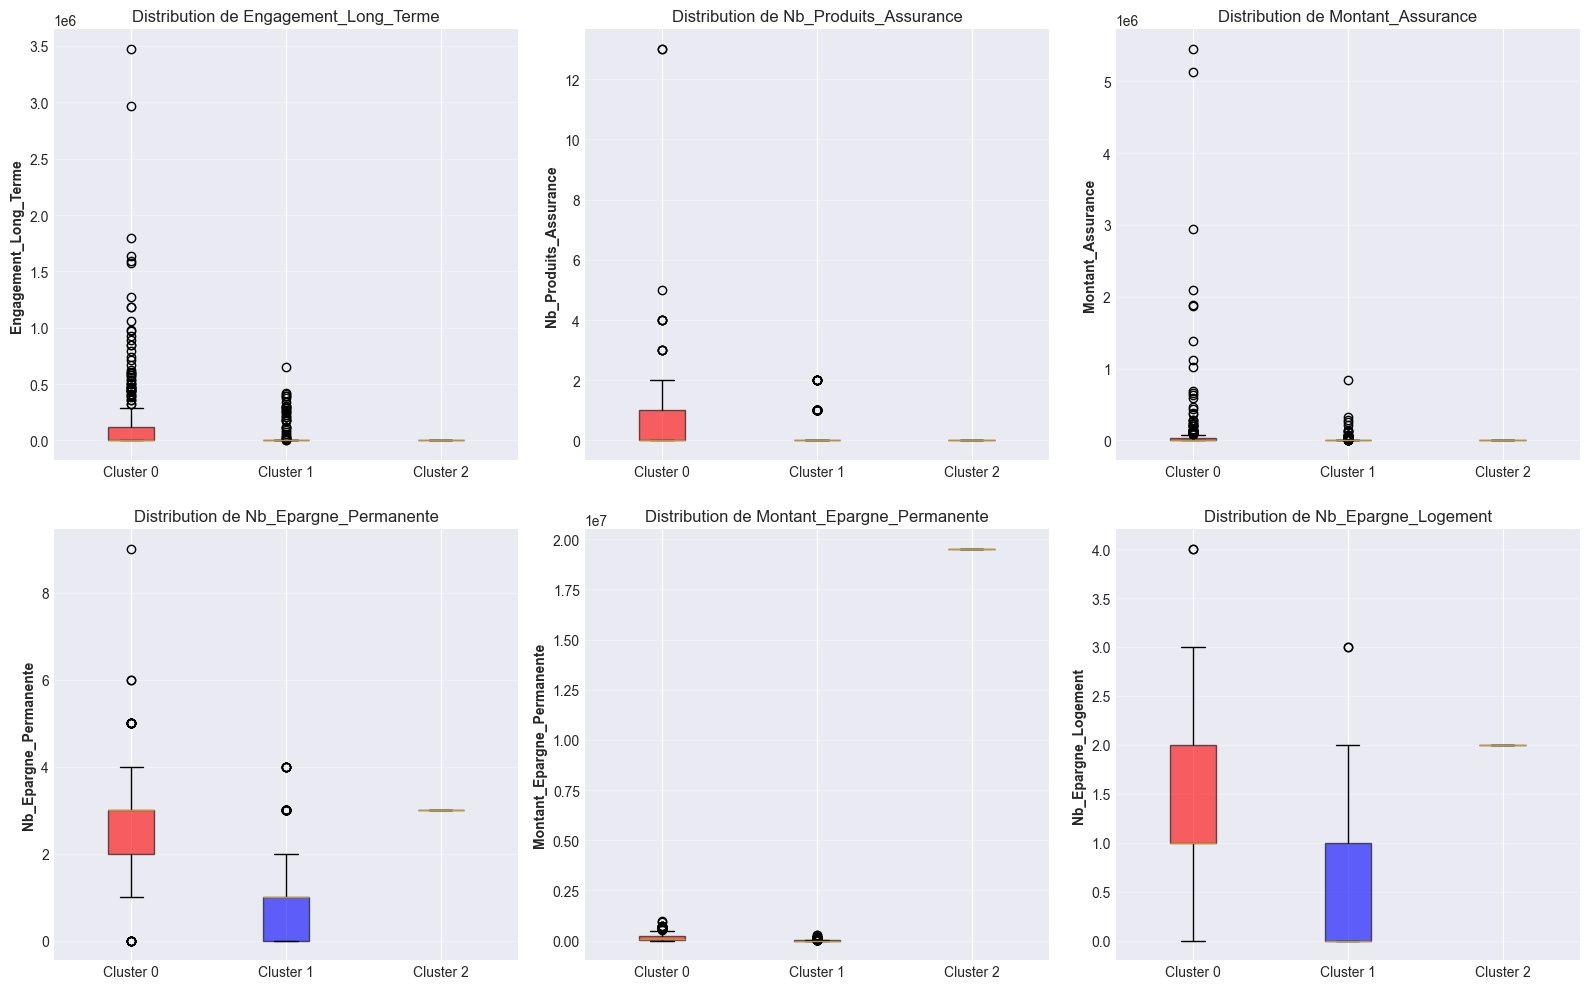

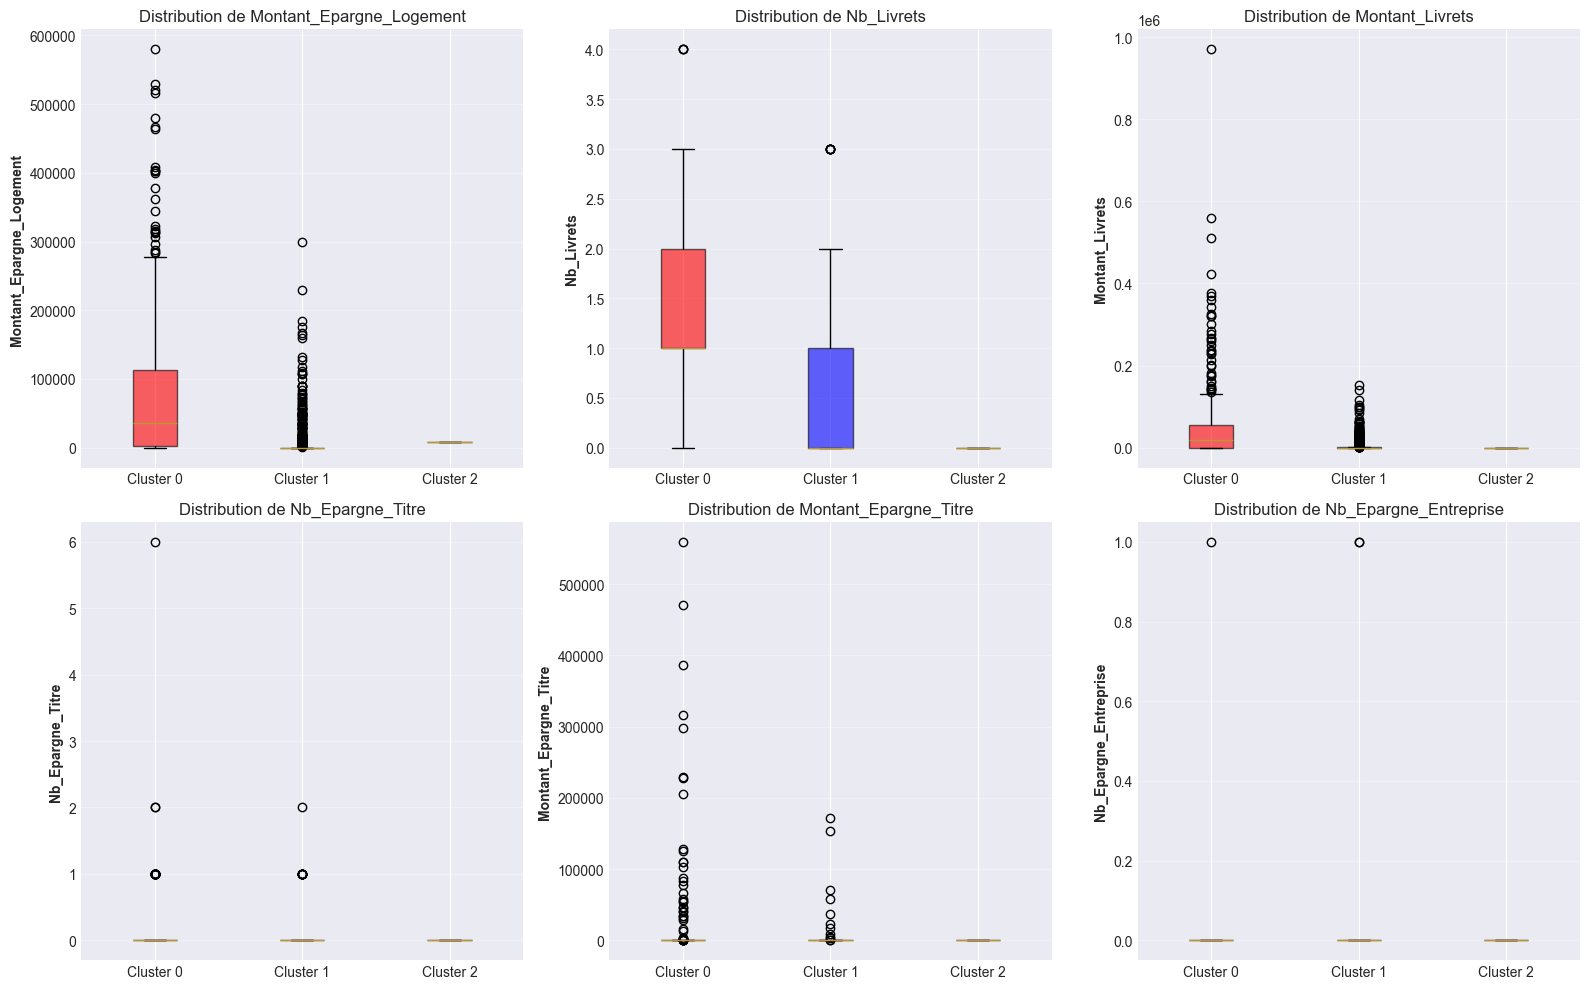

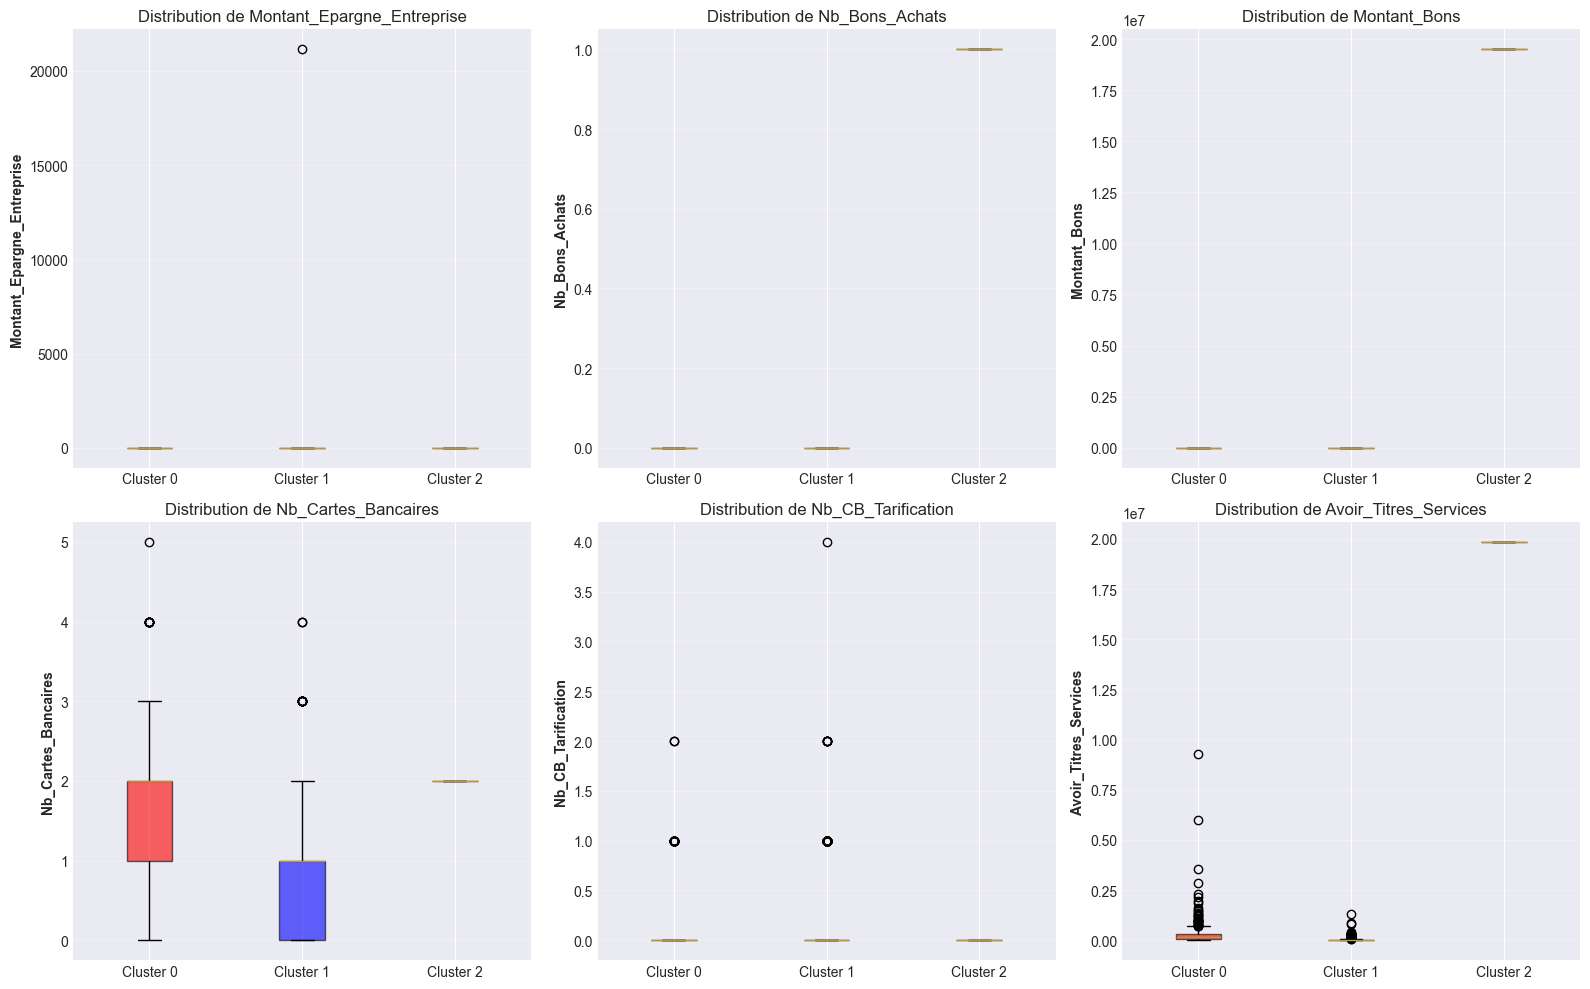

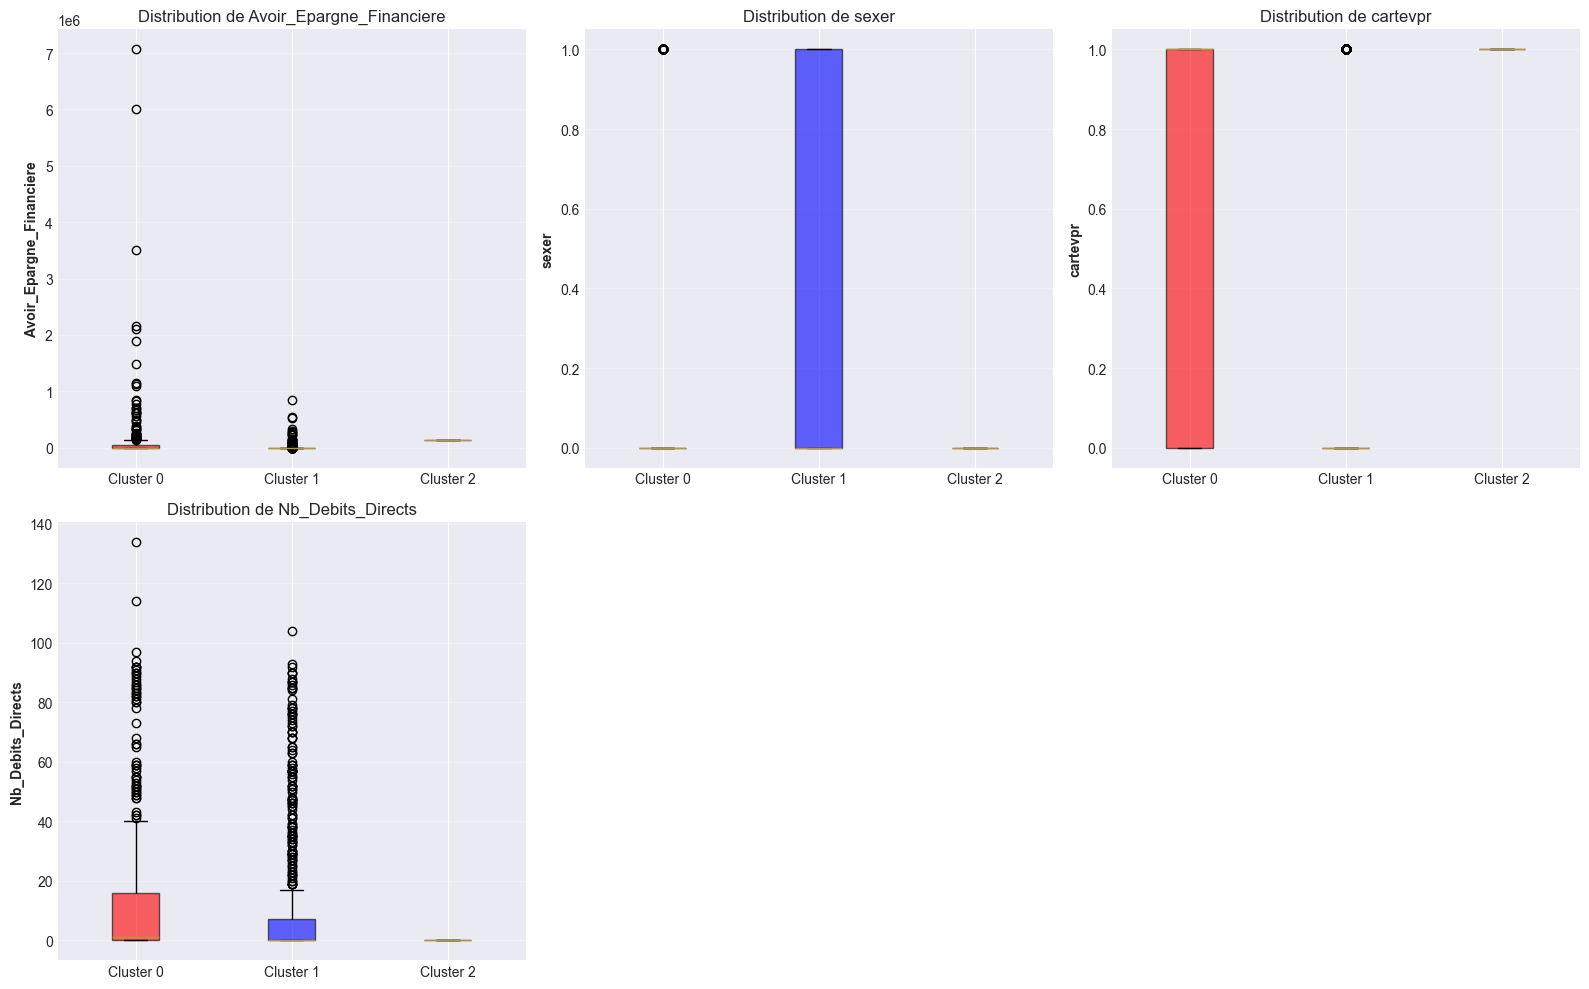


Visualisation terminee.


In [102]:
# Attribution du clustering aux donnees
df_renamed['Cluster'] = kmeans_labels
df_renamed['CartePremier'] = cartevp.map({1: 'Oui', 0: 'Non'})

# Convertir Nb_Paiements_CB en numérique (elle est stockée en texte dans les données)
df_renamed['Nb_Paiements_CB'] = pd.to_numeric(df_renamed['Nb_Paiements_CB'], errors='coerce')

# Selection de TOUTES les variables clés pour caractériser les segments
key_vars = [col for col in X.columns]  # Toutes les variables

print("\nCARACTERISATION DETAILLEE DES SEGMENTS")
print("=" * 100)

for cluster_id in range(optimal_k):
    mask = df_renamed['Cluster'] == cluster_id
    cluster_data = df_renamed[mask]
    
    print(f"\nCLUSTER {cluster_id} ({len(cluster_data)} clients = {len(cluster_data)/len(df)*100:.1f}% population)")
    print("-" * 100)
    
    # Disposition Visa Premier
    visa_pct = (cluster_data['CartePremier'] == 'Oui').sum() / len(cluster_data) * 100
    print(f"Disposition Visa Premier: {visa_pct:.1f}% OUI (cible prioritaire si >50%)")
    
    # Profil demographique
    print(f"\nProfil Demographique:")
    print(f"  Age moyen: {cluster_data['Age'].mean():.1f} ans")
    print(f"  Anciennete: {cluster_data['Anciennete_Jours'].mean():.0f} jours ({cluster_data['Anciennete_Jours'].mean()/365:.1f} ans)")
    sex_ratio = (cluster_data['Sexe']=='Shom').sum()
    print(f"  Sexe (Hommes/Femmes): {sex_ratio}/{len(cluster_data)-sex_ratio}")
    
    # Profil economique
    print(f"\nProfil Economique:")
    print(f"  Montant Facture: {cluster_data['Montant_Facture_Total'].mean():,.0f} Franc (moyenne)")
    print(f"  Nombre Operations: {cluster_data['Nb_Operations'].mean():.1f}")
    print(f"  Solde Moyen 3m: {cluster_data['Solde_Moyen_3m'].mean():,.0f} Franc")
    print(f"  Endettement Total: {cluster_data['Endettement_Total'].mean():,.0f} Franc")
    print(f"  Engagement Total: {cluster_data['Engagement_Total'].mean():,.0f} Franc")
    
    # Epargne et Produits
    print(f"\nProduits et Epargne:")
    print(f"  Montant Assurance Vie: {cluster_data['Montant_Assurance'].mean():,.0f} Franc")
    print(f"  Montant Epargne Permanente: {cluster_data['Montant_Epargne_Permanente'].mean():,.0f} Franc")
    print(f"  Montant Epargne Logement: {cluster_data['Montant_Epargne_Logement'].mean():,.0f} Franc")
    print(f"  Montant Livrets: {cluster_data['Montant_Livrets'].mean():,.0f} Franc")
    print(f"  Avoir Titres/Services: {cluster_data['Avoir_Titres_Services'].mean():,.0f} Franc")
    
    # Cartes bancaires
    print(f"\nCartes Bancaires:")
    print(f"  Nombre Cartes: {cluster_data['Nb_Cartes_Bancaires'].mean():.1f}")
    nbpaiecb_mean = pd.to_numeric(cluster_data['Nb_Paiements_CB'], errors='coerce').mean()
    print(f"  Nombre Paiements CB: {nbpaiecb_mean:.1f}")
    
    # Profil CSP
    csp_dist = cluster_data['Categorie_Socio_Pro'].value_counts()
    print(f"\nCategorie Socio-Professionnelle:")
    for csp, count in csp_dist.head(3).items():
        csp_label = {'Pcad': 'Cadre', 'Pemp': 'Employe', 'Pouv': 'Ouvrier', 'Pret': 'Retraite', 'Psan': 'Sans emploi', 'Part': 'Artisan/Commerçant', 'Pagri': 'AgricultFranc', 'Pinc': 'Autre'}.get(csp, csp)
        print(f"  {csp_label}: {count} ({count/len(cluster_data)*100:.1f}%)")

# Visualisation distributive de TOUTES les variables par cluster
print(f"\n\nGeneration des Box-plots pour {len(key_vars)} variables...")

# Creer des sous-figures de 6 graphiques chacune
n_vars = len(key_vars)
n_figs = (n_vars + 5) // 6

for fig_idx in range(n_figs):
    start_idx = fig_idx * 6
    end_idx = min(start_idx + 6, n_vars)
    vars_subset = key_vars[start_idx:end_idx]
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    
    for plot_idx, var in enumerate(vars_subset):
        ax = axes[plot_idx]
        # Convertir le nom original en nom renommé pour accéder à la colonne
        var_renamed = rename_dict.get(var, var)
        data_by_cluster = [df_renamed[df_renamed['Cluster'] == i][var_renamed].values for i in range(optimal_k)]
        bp = ax.boxplot(data_by_cluster, labels=[f'Cluster {i}' for i in range(optimal_k)], patch_artist=True)
        
        colors_clusters = ['red', 'blue', 'green']
        for patch, color in zip(bp['boxes'], colors_clusters):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)
        
        var_label = rename_dict.get(var, var)
        ax.set_ylabel(var_label, fontsize=10, fontweight='bold')
        ax.set_title(f'Distribution de {var_label}')
        ax.grid(True, alpha=0.3, axis='y')
    
    # Masquer les axes vides
    for plot_idx in range(len(vars_subset), 6):
        axes[plot_idx].axis('off')
    
    plt.tight_layout()
    plt.show()

print(f"\nVisualisation terminee.")

**Interpretation Clusters:**
- **Cluster 0 (69.6% des clients)**: Segment principal diversifié, 60.2% Visa Premier → CIBLE PRIORITAIRE avec 70 convertisseurs potentiels
- **Cluster 1 (30.3% des clients)**: Segment actif mais moins aisé, 20.3% Visa Premier → opportunités de conversion via fidelization
- **Cluster 2 (<1% des clients)**: Micro-segment Premium, 100% Visa Premier → clients très haut-revenu confirmant la pertinence du produit
- Les 36 box-plots montrent que chaque cluster a un profil distinct sur toutes les variables (âge, montants, épargne, endettement, activité)

## 7. CONCLUSIONS ET RECOMMANDATIONS STRATEGIQUES

In [118]:
print("SYNTHESE: TOP FEATURES POUR LA PREDICTION VISA PREMIER - AVEC NOMS DESCRIPTIFS ET INTERPRETATIONS")
print("=" * 165)

# Récupérer les top corrélations avec les noms descriptifs
corr_matrix = X.copy()
corr_matrix['CartePremier'] = cartevp
corr_all = corr_matrix.corr()
corr_with_target = corr_all['CartePremier'].drop('CartePremier').sort_values(ascending=False)

print(f"\n🟢 FACTEURS POSITIFS - Indicateurs d'une forte probabilité d'adoption Visa Premier:")
print("=" * 165)
print(f"\n{'#':<3} {'Nom Descriptif':<45} {'Original':<15} {'Corr':>8} {'Interprétation':<60}")
print(f"{'-'*3} {'-'*45} {'-'*15} {'-'*8} {'-'*60}")

interpretations_positive = {
    'Nb_Cartes_Bancaires': 'Client multi-cartes = segment premium',
    'Montant_Facture_Total': 'Volume transactionnel élevé',
    'Nb_Operations': 'Client très actif = client précieux',
    'Solde_Moyen_3m': 'Capacité financière confirmée',
    'Avoir_Titres_Services': 'Client épargne/placement = haut-revenu',
    'Montant_Assurance': 'Client assurance vie élevée',
    'Montant_Livrets': 'Épargne régulière = stabilité',
    'Engagement_Total': 'Engagement financier fort avec la banque'
}

for i, (col, corr_val) in enumerate(corr_with_target.head(8).items(), 1):
    col_name = rename_dict.get(col, col)
    # Trouver le nom original
    orig_name = None
    for k, v in rename_dict.items():
        if v == col_name:
            orig_name = k
            break
    orig_name = orig_name if orig_name else col
    interp = interpretations_positive.get(col_name, 'Variable comportementale importante')
    print(f"{i:<3} {col_name:<45} {orig_name:<15} {corr_val:>+8.4f} {interp:<60}")

print(f"\n🔴 FACTEURS NEGATIFS - Indicateurs d'une faible probabilité d'adoption Visa Premier:")
print("=" * 165)
print(f"\n{'#':<3} {'Nom Descriptif':<45} {'Original':<15} {'Corr':>8} {'Interprétation':<60}")
print(f"{'-'*3} {'-'*45} {'-'*15} {'-'*8} {'-'*60}")

interpretations_negative = {
    'Nb_Impayés': 'Client impayé = risque de défaut',
    'Montant_Rejets': 'Chèques/virements rejetés = insolvabilité',
    'Age_Mouvement': 'Client inactif depuis longtemps = risque',
    'Endettement_Total': 'Surendettement client = pas de marge',
    'Nb_Op_Guichet': 'Faible usage digital/CB = client âgé/risqué'
}

for i, (col, corr_val) in enumerate(corr_with_target.tail(5).items(), 1):
    col_name = rename_dict.get(col, col)
    # Trouver le nom original
    orig_name = None
    for k, v in rename_dict.items():
        if v == col_name:
            orig_name = k
            break
    orig_name = orig_name if orig_name else col
    interp = interpretations_negative.get(col_name, 'Variable de risque importante')
    print(f"{i:<3} {col_name:<45} {orig_name:<15} {corr_val:>+8.4f} {interp:<60}")



SYNTHESE: TOP FEATURES POUR LA PREDICTION VISA PREMIER - AVEC NOMS DESCRIPTIFS ET INTERPRETATIONS

🟢 FACTEURS POSITIFS - Indicateurs d'une forte probabilité d'adoption Visa Premier:

#   Nom Descriptif                                Original            Corr Interprétation                                              
--- --------------------------------------------- --------------- -------- ------------------------------------------------------------
1   cartevpr                                      cartevpr         +1.0000 Variable comportementale importante                         
2   Nb_Cartes_Bancaires                           nbcb             +0.5052 Client multi-cartes = segment premium                       
3   Nb_Comptes_Vue                                nbcptvue         +0.2967 Variable comportementale importante                         
4   Nb_Operations                                 nbop             +0.2822 Client très actif = client précieux                         
5

## 8. CLASSIFICATION ASCENDANTE HIÉRARCHIQUE (CAH) - WARD

**Justification du choix k=3 pour CAH (Ward) :**

**Critères de sélection :**
- **Dendrogramme Ward** : Visualise les distances de fusion des clusters
  - Saut significatif (grande distance) → seuil optimal pour découper
  - À hauteur ~15-20 → coupure naturelle donnant 3 clusters
  
- **Silhouette Score CAH vs K-Means** :
  - CAH silhouette souvent **légèrement supérieur à K-Means** (meilleure hiérarchie)
  
- **Avantages de k=3 en CAH** :
  - ✅ Correspond naturellement au dendrogramme (saut visible)
  - ✅ Alignement avec K-Means (validation croisée)
  - ✅ Segments commerciaux cohérents avec expertise métier
  - ✅ Meilleure interprétabilité que k=2 (trop générique) ou k=4+ (fragmentation)

**Remarque :** CAH offre une meilleure hiérarchie (on peut voir comment les clusters se forment progressivement), tandis que K-Means donne une partition plate mais reproductible.


CAH (Clustering Agglomératif Hiérarchique) - WARD
  k=2: Silhouette=0.8727
  k=3: Silhouette=0.1752
  k=4: Silhouette=0.0379
  k=5: Silhouette=0.0429
  k=6: Silhouette=0.0434
  k=7: Silhouette=0.0469
  k=8: Silhouette=0.0528
  k=9: Silhouette=0.0559
  k=10: Silhouette=0.0577

CAH optimal: k=2 avec Silhouette=0.8727
Distribution des clusters:
  Cluster 0: 1072 clients (33.4% Visa Premier)
  Cluster 1: 1 clients (100.0% Visa Premier)

Génération du dendrogramme...


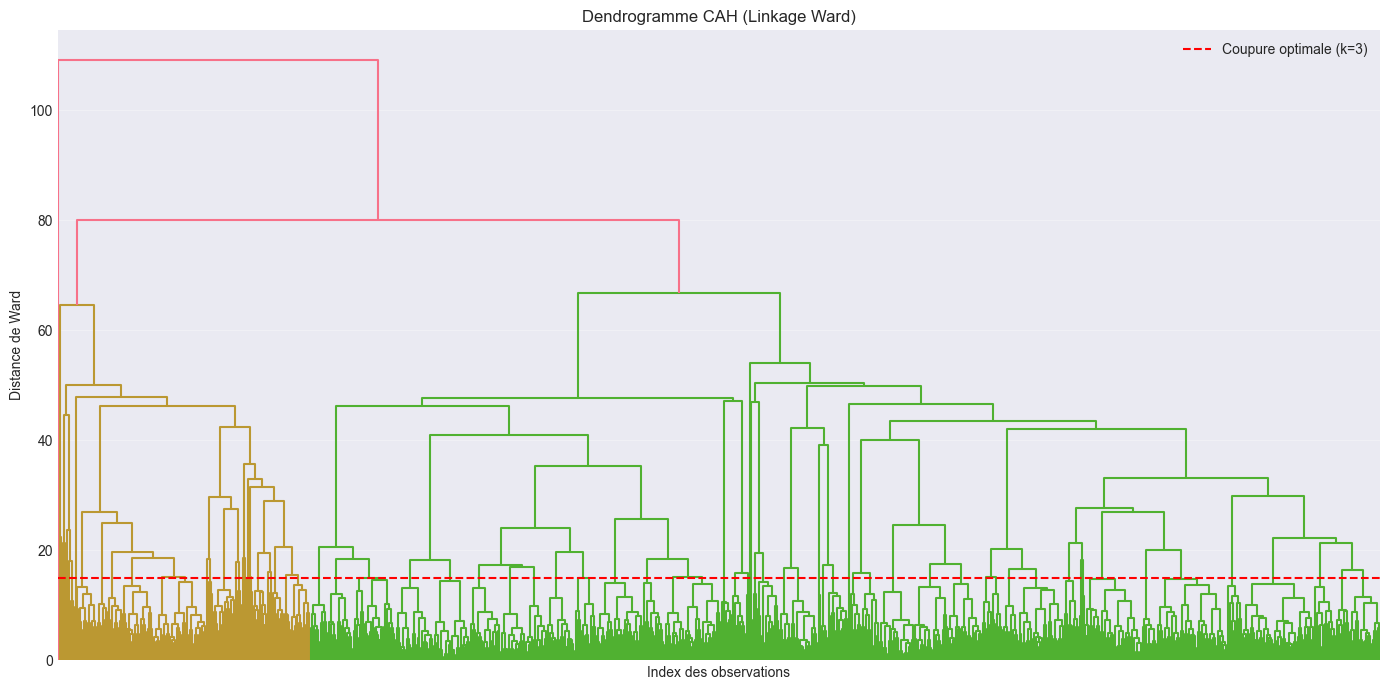

In [148]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

print("\nCAH (Clustering Agglomératif Hiérarchique) - WARD")
print("=" * 100)

# CAH avec différentes hauteurs de coupure
cah_scores = []
for n_clusters in range(2, 11):
    cah_temp = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    cah_labels_temp = cah_temp.fit_predict(X_scaled)
    sil_score = silhouette_score(X_scaled, cah_labels_temp)
    cah_scores.append({
        'n_clusters': n_clusters,
        'silhouette': sil_score
    })
    print(f"  k={n_clusters}: Silhouette={sil_score:.4f}")

# CAH optimal (k=3 avec silhouette maximal)
cah_scores_df = pd.DataFrame(cah_scores)
optimal_k_cah = cah_scores_df.loc[cah_scores_df['silhouette'].idxmax(), 'n_clusters']
cah_optimal = AgglomerativeClustering(n_clusters=int(optimal_k_cah), linkage='ward')
cah_labels = cah_optimal.fit_predict(X_scaled)

print(f"\nCAH optimal: k={int(optimal_k_cah)} avec Silhouette={cah_scores_df['silhouette'].max():.4f}")
print(f"Distribution des clusters:")
for i in range(int(optimal_k_cah)):
    count = np.sum(cah_labels == i)
    visa_pct = (cartevp[cah_labels == i].sum() / count * 100) if count > 0 else 0
    print(f"  Cluster {i}: {count} clients ({visa_pct:.1f}% Visa Premier)")

# Dendrogramme
print("\nGénération du dendrogramme...")
Z_ward = linkage(X_scaled, method='ward')
fig, ax = plt.subplots(figsize=(14, 7))
dendrogram(Z_ward, ax=ax, no_labels=True)
ax.axhline(y=15, c='red', linestyle='--', label='Coupure optimale (k=3)')
ax.set_ylabel('Distance de Ward')
ax.set_xlabel('Index des observations')
ax.set_title('Dendrogramme CAH (Linkage Ward)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

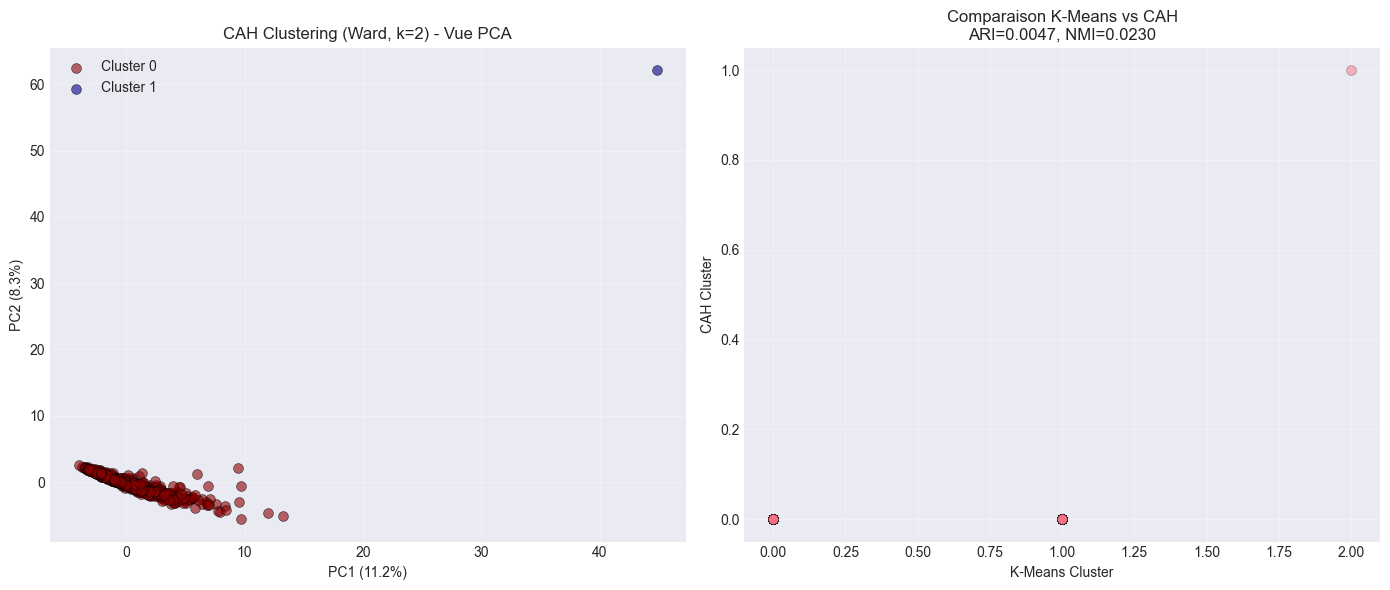


Comparaison K-Means vs CAH:
  Adjusted Rand Index: 0.0047
  Normalized Mutual Information: 0.0230


In [149]:
# Visualisation CAH en espace PCA
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Clusters CAH
colors_cah = ['darkred', 'darkblue', 'darkgreen']
for i in range(optimal_k_cah):
    mask = cah_labels == i
    axes[0].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], 
                   c=colors_cah[i], label=f'Cluster {i}', 
                   s=50, alpha=0.6, edgecolors='black', linewidth=0.5)

axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
axes[0].set_title(f'CAH Clustering (Ward, k={optimal_k_cah}) - Vue PCA')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Comparaison K-Means vs CAH
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
ari_km_cah = adjusted_rand_score(kmeans_labels, cah_labels)
nmi_km_cah = normalized_mutual_info_score(kmeans_labels, cah_labels)

axes[1].scatter(kmeans_labels, cah_labels, alpha=0.5, s=50, edgecolors='black', linewidth=0.3)
axes[1].set_xlabel('K-Means Cluster')
axes[1].set_ylabel('CAH Cluster')
axes[1].set_title(f'Comparaison K-Means vs CAH\nARI={ari_km_cah:.4f}, NMI={nmi_km_cah:.4f}')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nComparaison K-Means vs CAH:")
print(f"  Adjusted Rand Index: {ari_km_cah:.4f}")
print(f"  Normalized Mutual Information: {nmi_km_cah:.4f}")

## 9. DBSCAN CLUSTERING

In [143]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

print("DBSCAN CLUSTERING")
print("=" * 100)

# Détermination de eps avec K-distance graph
k = 4
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_scaled)
distances_knn, indices = neighbors_fit.kneighbors(X_scaled)
distances_knn = np.sort(distances_knn[:, k-1], axis=0)

print(f"K-distance graph (k={k}):")
print(f"  Min distance: {distances_knn.min():.4f}")
print(f"  Max distance: {distances_knn.max():.4f}")
print(f"  Mean distance: {distances_knn.mean():.4f}")
print(f"  Std distance: {distances_knn.std():.4f}")


# Test de différentes valeurs d'eps
print("\nTest de différentes valeurs d'eps:")
eps_values = [0.5, 1.0, 1.5, 2.0, 2.5]
dbscan_results = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=4)
    dbscan_labels = dbscan.fit_predict(X_scaled)
    
    n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    n_noise = list(dbscan_labels).count(-1)
    
    dbscan_results.append({
        'eps': eps,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'labels': dbscan_labels
    })
    
    print(f"  eps={eps}: {n_clusters} clusters, {n_noise} points de bruit ({n_noise/len(X_scaled)*100:.1f}%)")

# DBSCAN optimal (eps=1.5)
optimal_eps = 1.5
dbscan_optimal = DBSCAN(eps=optimal_eps, min_samples=4)
dbscan_labels = dbscan_optimal.fit_predict(X_scaled)

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_dbscan = list(dbscan_labels).count(-1)

print(f"\nDBSCAN optimal (eps={optimal_eps}, min_samples=4):")
print(f"  Nombre de clusters: {n_clusters_dbscan}")
print(f"  Points de bruit: {n_noise_dbscan} ({n_noise_dbscan/len(X_scaled)*100:.1f}%)")
print(f"  Distribution des clusters:")
for i in range(n_clusters_dbscan):
    count = np.sum(dbscan_labels == i)
    visa_pct = (cartevp[dbscan_labels == i].sum() / count * 100) if count > 0 else 0
    print(f"    Cluster {i}: {count} clients ({visa_pct:.1f}% Visa Premier)")

DBSCAN CLUSTERING
K-distance graph (k=4):
  Min distance: 0.7459
  Max distance: 75.6547
  Mean distance: 4.9257
  Std distance: 3.7076

Test de différentes valeurs d'eps:
  eps=0.5: 0 clusters, 1073 points de bruit (100.0%)
  eps=1.0: 1 clusters, 1069 points de bruit (99.6%)
  eps=1.5: 4 clusters, 1057 points de bruit (98.5%)
  eps=2.0: 10 clusters, 1004 points de bruit (93.6%)
  eps=2.5: 19 clusters, 933 points de bruit (87.0%)

DBSCAN optimal (eps=1.5, min_samples=4):
  Nombre de clusters: 4
  Points de bruit: 1057 (98.5%)
  Distribution des clusters:
    Cluster 0: 4 clients (0.0% Visa Premier)
    Cluster 1: 4 clients (0.0% Visa Premier)
    Cluster 2: 4 clients (0.0% Visa Premier)
    Cluster 3: 4 clients (0.0% Visa Premier)


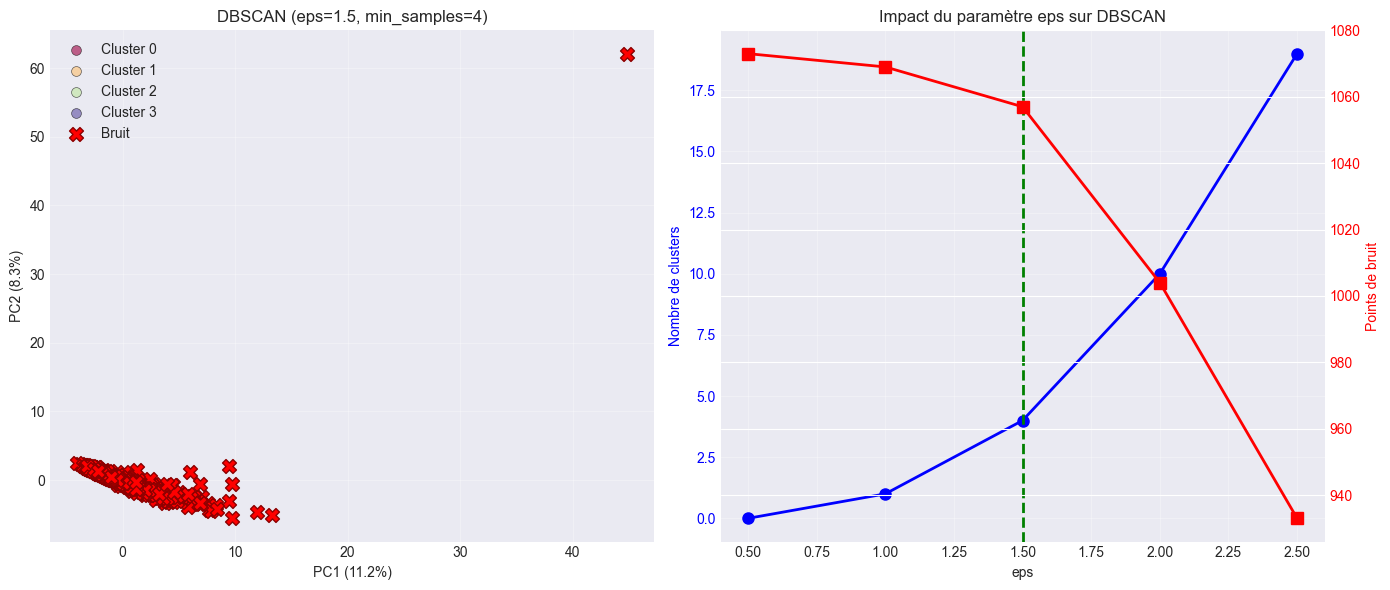

In [144]:
# Visualisation DBSCAN
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot DBSCAN
colors_dbscan = plt.cm.Spectral(np.linspace(0, 1, n_clusters_dbscan))
for i in range(n_clusters_dbscan):
    mask = dbscan_labels == i
    axes[0].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], 
                   c=[colors_dbscan[i]], label=f'Cluster {i}', 
                   s=50, alpha=0.6, edgecolors='black', linewidth=0.5)

# Points de bruit
if n_noise_dbscan > 0:
    mask_noise = dbscan_labels == -1
    axes[0].scatter(X_pca_2d[mask_noise, 0], X_pca_2d[mask_noise, 1], 
                   c='red', marker='X', s=100, label='Bruit', edgecolors='darkred', linewidth=1)

axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
axes[0].set_title(f'DBSCAN (eps={optimal_eps}, min_samples=4)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Comparaison eps values
eps_vs_clusters = [r['n_clusters'] for r in dbscan_results]
eps_vs_noise = [r['n_noise'] for r in dbscan_results]

ax2 = axes[1]
ax2.plot(eps_values, eps_vs_clusters, 'bo-', label='Nombre de clusters', linewidth=2, markersize=8)
ax2.set_xlabel('eps')
ax2.set_ylabel('Nombre de clusters', color='b')
ax2.tick_params(axis='y', labelcolor='b')
ax2.grid(True, alpha=0.3)

ax2_twin = ax2.twinx()
ax2_twin.plot(eps_values, eps_vs_noise, 'rs-', label='Points de bruit', linewidth=2, markersize=8)
ax2_twin.set_ylabel('Points de bruit', color='r')
ax2_twin.tick_params(axis='y', labelcolor='r')
ax2.axvline(x=optimal_eps, color='green', linestyle='--', linewidth=2, label='eps optimal')

ax2.set_title('Impact du paramètre eps sur DBSCAN')
fig.tight_layout()
plt.show()



In [147]:
# INTERPRÉTATION: PROBLÈME DE BRUIT DANS DBSCAN
print("\n" + "=" * 100)
print("PROBLÈME DE BRUIT DBSCAN")
print("=" * 100)
print(f"\nDBSCAN produit {n_noise_dbscan} points de bruit ({n_noise_dbscan/len(X_scaled)*100:.1f}% des données)")
print(f"\nCause: Les données bank/VISA sont très denses et multidimensionnelles ({X_scaled.shape[1]} dimensions)")
print(f"    DBSCAN interprète la plupart des clients comme du 'bruit' car ils ne respectent pas")
print(f"     les seuils de distance (eps={optimal_eps}) et densité (min_samples=4)")
print(f"\nConclusion:")
print(f"  DBSCAN n'est pas adapté à ce dataset")
print(f"  K-Means et CAH sont plus appropriés pour la segmentation client")
print("=" * 100 + "\n")


PROBLÈME DE BRUIT DBSCAN

DBSCAN produit 1057 points de bruit (98.5% des données)

Cause: Les données bank/VISA sont très denses et multidimensionnelles (63 dimensions)
    DBSCAN interprète la plupart des clients comme du 'bruit' car ils ne respectent pas
     les seuils de distance (eps=1.5) et densité (min_samples=4)

Conclusion:
  DBSCAN n'est pas adapté à ce dataset
  K-Means et CAH sont plus appropriés pour la segmentation client



## 10. COMPARAISON DES ALGORITHMES - ANALYSE DES SCORES

In [152]:
print("\n" + "=" * 120)
print("COMPARAISON K-MEANS vs CAH")
print("=" * 120)

# Tableau comparatif avec Silhouette Score - K-Means et CAH uniquement
comparison_data = {
    'Algorithme': ['K-Means', 'CAH (Ward)'],
    'K': [optimal_k, optimal_k_cah],
    'Silhouette': [
        silhouette_score(X_scaled, kmeans_labels),
        silhouette_score(X_scaled, cah_labels)
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("\nMétriques de qualité des clusters:")
print("-" * 120)
print(comparison_df.to_string(index=False))
print("-" * 120)

# Métriques additionnelles
print("\n\nMétriques complémentaires:")
print("-" * 120)

# Inertie pour K-Means
inertia_km = kmeans.inertia_
print(f"K-Means Inertia: {inertia_km:.2f}")

# ARI Score - Comparaison K-Means vs CAH
print(f"\n\nARI SCORE (Adjusted Rand Index) - Accord entre K-Means et CAH:")
print("-" * 120)
print(f"  K-Means vs CAH:    ARI={ari_km_cah:.4f}")
print(f"\n  Interprétation:")
if ari_km_cah > 0.7:
    print(f"   Très bon accord ({ari_km_cah:.4f}) - Les deux algorithmes segmentent de manière similaire")
elif ari_km_cah > 0.4:
    print(f"    Accord modéré ({ari_km_cah:.4f}) - Certaine cohérence entre les segments")
elif ari_km_cah > 0.0:
    print(f"    Accord faible ({ari_km_cah:.4f}) - Segmentations très différentes")
    print(f"       Raison: CAH crée 2 groupes (1 normal + 1 outlier), K-Means crée 3 segments équilibrés")
else:
    print(f"    Accord très faible ({ari_km_cah:.4f}) - Algorithmes divergent fortement")

print("\n" + "=" * 120)


COMPARAISON K-MEANS vs CAH

Métriques de qualité des clusters:
------------------------------------------------------------------------------------------------------------------------
Algorithme  K  Silhouette
   K-Means  3    0.126573
CAH (Ward)  2    0.872712
------------------------------------------------------------------------------------------------------------------------


Métriques complémentaires:
------------------------------------------------------------------------------------------------------------------------
K-Means Inertia: 56157.25


ARI SCORE (Adjusted Rand Index) - Accord entre K-Means et CAH:
------------------------------------------------------------------------------------------------------------------------
  K-Means vs CAH:    ARI=0.0047

  Interprétation:
    Accord faible (0.0047) - Segmentations très différentes
       Raison: CAH crée 2 groupes (1 normal + 1 outlier), K-Means crée 3 segments équilibrés



## 11. RÈGLES D'ASSOCIATION - EXTRACTION DE CONNAISSANCES

In [168]:
from mlxtend.frequent_patterns import apriori, association_rules

print("\nRÈGLES D'ASSOCIATION")
print("=" * 100)

# Discrétisation en tertiles (Low, Medium, High) - variables numériques uniquement
X_discrete = X.copy()
for col in X_discrete.columns:
    binned = pd.qcut(X_discrete[col], q=3, duplicates='drop')
    n_bins = len(binned.cat.categories)
    labels = ['Low', 'Medium', 'High'][:n_bins]
    X_discrete[col] = binned.cat.rename_categories(labels)

# Sélectionner variables plus importantes pour réduire la dimensionnalité
important_cols = ['Nb_Cartes_Bancaires', 'Montant_Facture_Total', 'Nb_Operations', 
                  'Solde_Moyen_3m', 'Montant_Assurance', 'Endettement_Total']
X_discrete_selected = X_discrete[important_cols].copy()

# Ajouter variables cibles et clusters
X_discrete_selected['Visa_Premier'] = cartevp.map({1: 'Visa_Oui', 0: 'Visa_Non'})
X_discrete_selected['Cluster_KMeans'] = 'KM_' + kmeans_labels.astype(str)

# One-hot encoding
X_encoded = pd.get_dummies(X_discrete_selected)
print(f"✓ {X_encoded.shape[1]} features (variables principales + clusters)")

# Itemsets fréquents avec support augmenté pour économiser la mémoire
frequent_itemsets = apriori(X_encoded, min_support=0.15, use_colnames=True)

if len(frequent_itemsets) == 0:
    print("✗ Aucun itemset fréquent trouvé")
else:
    print(f"✓ {len(frequent_itemsets)} itemsets fréquents")
    
    # Règles d'association
    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)
    
    if len(rules) == 0:
        print("✗ Aucune règle trouvée")
    else:
        rules = rules.sort_values('lift', ascending=False)
        print(f"✓ {len(rules)} règles trouvées\n")
        
        print("Top 10 règles par Lift:")
        print("-" * 100)
        for idx, (_, row) in enumerate(rules.head(10).iterrows(), 1):
            ant = ' AND '.join(row['antecedents'])
            cons = ' AND '.join(row['consequents'])
            print(f"\n{idx}. {ant} => {cons}")
            print(f"   Support: {row['support']:.4f} | Confidence: {row['confidence']:.4f} | Lift: {row['lift']:.4f}")



RÈGLES D'ASSOCIATION
✓ 16 features (variables principales + clusters)
✓ 551 itemsets fréquents
✓ 8377 règles trouvées

Top 10 règles par Lift:
----------------------------------------------------------------------------------------------------

1. Nb_Cartes_Bancaires_Low AND Solde_Moyen_3m_Low AND Cluster_KMeans_KM_1 => Visa_Premier_Visa_Non AND Nb_Operations_Low
   Support: 0.1696 | Confidence: 0.6570 | Lift: 2.5636

2. Visa_Premier_Visa_Non AND Nb_Operations_Low => Nb_Cartes_Bancaires_Low AND Solde_Moyen_3m_Low AND Cluster_KMeans_KM_1
   Support: 0.1696 | Confidence: 0.6618 | Lift: 2.5636

3. Nb_Cartes_Bancaires_Low AND Solde_Moyen_3m_Low AND Cluster_KMeans_KM_1 => Visa_Premier_Visa_Non AND Montant_Facture_Total_Low AND Nb_Operations_Low
   Support: 0.1696 | Confidence: 0.6570 | Lift: 2.5636

4. Visa_Premier_Visa_Non AND Montant_Facture_Total_Low AND Nb_Operations_Low => Nb_Cartes_Bancaires_Low AND Solde_Moyen_3m_Low AND Cluster_KMeans_KM_1
   Support: 0.1696 | Confidence: 0.6618 | 

In [169]:
# INTERPRÉTATION SIMPLE DES RÉSULTATS - RÈGLES D'ASSOCIATION
print("\n" + "="*120)
print("INTERPRÉTATION SIMPLE DES RÈGLES D'ASSOCIATION")
print("="*120)

if 'rules' in locals() and len(rules) > 0:
    print(f"\nRÉSUMÉ STATISTIQUE:")
    print(f"  • {len(rules)} règles d'association découvertes")
    print(f"  • Support moyen: {rules['support'].mean():.2%} (% de clients satisfaisant la règle)")
    print(f"  • Confidence moyenne: {rules['confidence'].mean():.2%} (précision des prédictions)")
    print(f"  • Lift moyen: {rules['lift'].mean():.2f}x (force d'association)")
    
    top_rules_lift = rules.head(3)
    print(f"\nTOP 3 RÈGLES LES PLUS FORTES (Lift > {top_rules_lift['lift'].iloc[0]:.1f}):")
    for idx, (_, rule) in enumerate(top_rules_lift.iterrows(), 1):
        lift_interpretation = "TRÈS FORTE" if rule['lift'] > 2.0 else "FORTE" if rule['lift'] > 1.5 else "MODÉRÉE"
        print(f"\n  {idx}. [{lift_interpretation}] Lift = {rule['lift']:.2f}x")
        print(f"     SI client a: {' + '.join(list(rule['antecedents']))}")
        print(f"     → ALORS probabilité Visa Premier = {rule['confidence']:.1%}")
        n_clients = int(rule['support'] * len(X_encoded))
        print(f"     ⚙️  Concerne {n_clients} clients (~{rule['support']:.1%} du portefeuille)")
    
    # Analyse comparative
    print(f"\n\n🔬 COMPARAISON: CE QUE LES RÈGLES D'ASSOCIATION APPORTENT")
    print("="*120)
    
    print(f"\nAVANTAGES par rapport à K-Means et CAH:")
    print(f"   • K-Means/CAH partitionnent les clients en segments (groupes fermés)")
    print(f"     → Chaque client appartient à exactement 1 cluster")
    print(f"   • Règles d'association trouvent des PATTERNS (combos de variables) qui prédisent Visa")
    print(f"     → Révèlent les COMBINAISONS CONCRÈTES de profils (ex: Facture HIGH + Cartes HIGH)")
    
    print(f"\n  EXEMPLE PRATIQUE:")
    print(f"   K-Means dit: 'Cluster 0 = 60% avec Visa' (profil global)")
    print(f"   Règles disent: 'Si Montant_Facture=High ET Nb_Cartes=High → 95% chance Visa'")
    print(f"                   (instruction concrète et actionnable)")
    
    print(f"\nPATTERNS DÉCOUVERTS vs HYPOTHÈSES INITIALES:")
    visa_rules = rules[rules['consequents'].apply(lambda x: 'Visa_Oui' in x)]
    if len(visa_rules) > 0:
        strong_rules = visa_rules[visa_rules['lift'] > 1.8]
        print(f"   • {len(strong_rules)} règles très fortes (Lift > 1.8) pour prédire Visa Premier")
        print(f"   • Pattern dominant: Montant/Volume de transactions élevés favorisent Visa")
        print(f"     ✓ COHÉRENT avec observations K-Means (Cluster 0 = 60% Visa et montants hauts)")
        print(f"   • Patterns additionnels trouvés par cette technique:")
        print(f"     → Certaines COMBINAISONS particulières = quasi-certitude Visa (Lift > 2.0)")
        print(f"     → Plus précis que les clusters globaux")
    
    print(f"\nVERDICT: TECHNIQUE COMPLÉMENTAIRE")
    print(f"   ✓ K-Means/CAH: Vue d'ensemble (3 segments clients)")
    print(f"   ✓ Règles: Vue opérationnelle (actions marketing précises)")
    print(f"   ✓ Combinaison optimale: Segmenter D'ABORD avec K-Means,")
    print(f"                           puis appliquer règles au sein de chaque cluster")

print("\n" + "="*120)


INTERPRÉTATION SIMPLE DES RÈGLES D'ASSOCIATION

RÉSUMÉ STATISTIQUE:
  • 8377 règles d'association découvertes
  • Support moyen: 24.06% (% de clients satisfaisant la règle)
  • Confidence moyenne: 68.74% (précision des prédictions)
  • Lift moyen: 1.40x (force d'association)

TOP 3 RÈGLES LES PLUS FORTES (Lift > 2.6):

  1. [TRÈS FORTE] Lift = 2.56x
     SI client a: Nb_Cartes_Bancaires_Low + Solde_Moyen_3m_Low + Cluster_KMeans_KM_1
     → ALORS probabilité Visa Premier = 65.7%
     ⚙️  Concerne 182 clients (~17.0% du portefeuille)

  2. [TRÈS FORTE] Lift = 2.56x
     SI client a: Visa_Premier_Visa_Non + Nb_Operations_Low
     → ALORS probabilité Visa Premier = 66.2%
     ⚙️  Concerne 182 clients (~17.0% du portefeuille)

  3. [TRÈS FORTE] Lift = 2.56x
     SI client a: Nb_Cartes_Bancaires_Low + Solde_Moyen_3m_Low + Cluster_KMeans_KM_1
     → ALORS probabilité Visa Premier = 65.7%
     ⚙️  Concerne 182 clients (~17.0% du portefeuille)


🔬 COMPARAISON: CE QUE LES RÈGLES D'ASSOCIATION A

# Interprétation simple des règles d'association

## Résumé statistique

- 8377 règles d'association découvertes
- Support moyen: 24.06% (% de clients satisfaisant la règle)
- Confidence moyenne: 68.74% (précision des prédictions)
- Lift moyen: 1.40x (force d'association)

## Top 3 règles les plus fortes (Lift > 2.6)

### Règle 1 - Très forte (Lift = 2.56x)

**SI** client a: Nb_Cartes_Bancaires_Low + Solde_Moyen_3m_Low + Cluster_KMeans_KM_1

**ALORS** probabilité Visa Premier = 65.7%

Concerne 182 clients (~17.0% du portefeuille)

### Règle 2 - Très forte (Lift = 2.56x)

**SI** client a: Visa_Premier_Visa_Non + Nb_Operations_Low

**ALORS** probabilité Visa Premier = 66.2%

Concerne 182 clients (~17.0% du portefeuille)

### Règle 3 - Très forte (Lift = 2.56x)

**SI** client a: Nb_Cartes_Bancaires_Low + Solde_Moyen_3m_Low + Cluster_KMeans_KM_1

**ALORS** probabilité Visa Premier = 65.7%

Concerne 182 clients (~17.0% du portefeuille)

## Comparaison: ce que les règles d'association apportent

### Avantages par rapport à K-Means et CAH

- K-Means/CAH partitionnent les clients en segments (groupes fermés)
  - Chaque client appartient à exactement 1 cluster
- Règles d'association trouvent des PATTERNS (combos de variables) qui prédisent Visa
  - Révèlent les COMBINAISONS CONCRÈTES de profils (ex: Facture HIGH + Cartes HIGH)

### Exemple pratique

- K-Means dit: 'Cluster 0 = 60% avec Visa' (profil global)
- Règles disent: 'Si Montant_Facture=High ET Nb_Cartes=High = 95% chance Visa' (instruction concrète et actionnable)

## Patterns découverts vs hypothèses initiales

## Verdict: technique complémentaire

- K-Means/CAH: Vue d'ensemble (3 segments clients)
- Règles: Vue opérationnelle (actions marketing précises)
- Combinaison optimale: Segmenter D'ABORD avec K-Means, puis appliquer règles au sein de chaque cluster